# Combined DL and TROPoe Eclipse Analysis

## Introduction

Based on previous scripts, this notebook explores eclipse behavior at a variety of sites, using both Doppler lidar and TROPoe output from AERI and ASSIST instruments. A key component of this analysis is the use of calculated PBL heights from Julia Simonson's code, based on the TROPoe PBLH code. This way, we can normalize behavior based on PBLH. 

This code is going to go through several steps:
1. Read in the TROPoe and DLID data for a particular case into a data class.  
2. Apply Julia's code to calculte PBLH from TROPoe
3. Evalute the characteristic performance of PBL vertical velocity and temperature as a function of height.
4. Do the same, but for normailzed heights relative to PBLH.
5. Write a paper, win Nobel prize.

## Preliminary Matters

Load the appropriate modules.

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import glob
import netCDF4
from scipy import interpolate as interp

Identify appropriate paths and initilize constants.

In [2]:
tropOEpath = '/data/eclipse/tropoe'
lidarPath = '/data/eclipse/dlfpt'

timeNew = np.linspace(-4,4,3600*8+1)
heightNew = np.arange(15,2025,30)


Record the characteristics of the eclipses: dates, times, obscurities, that kind of thing. Sincve we now know how many sites and datews we have, we can also initiliaze our blank matrices.

In [3]:
sgpEclipseDates = np.array([20120521, 20170821, 20231014, 20240408])
sgpEclipseTimes = np.array([1+31/60,18+4/60, 16+48/60, 18+47/60])
sgpEclipseMags = np.array([0.859, 0.903, 0.796, 0.914])
sgpTimeZone= np.array([-5,-5,-5,-5])
sgpEclipseSites = np.array(['C1','E32','E37','E39','E41'])
sgpEclipseFacilities= np.array(['sgp','sgp','sgp','sgp','sgp'])

nsaEclipseDates = np.array([20120520, 20141023, 20170821, 20210610])
nsaEclipseTimes = np.array([11+13/60, 19+55/60, 17+29/60, 10+57/60])
nsEclipseMags = np.array([0.482, 0.695, 0.335,0.849])
nsaTimeZone = np.array([-9,-9,-9,-9])
nsaEclipseSites= np.array(['C1'])
nsaEclipseFacilities = np.array(['nsa'])

enaEclipseDates = np.array([20150320,20170821,20210610,20231014,20250329])
enaEclipseTimes = np.array([8+51/60,19+26/60, 9+20/60, 18+42/60, 10+16/60]) 
enaEclipseMags = np.array([0.801, 0.386, 0.384, 0.026, 0.618])
enaTimeZone = np.array([-1,0,0,0,-1])
enaEclipseSites= np.array(['C1'])
enaEclipseFacilities = np.array(['ena'])


wPrime = np.zeros((len(timeNew), len(heightNew)))
wVar = np.zeros((len(timeNew), len(heightNew), len(sgpEclipseSites)*len(sgpEclipseDates)))
saveDate = np.zeros(len(timeNew) * len(heightNew))

eclipseFacilities = sgpEclipseFacilities
eclipseSites = sgpEclipseSites
eclipseDates = sgpEclipseDates
eclipseTimes = sgpEclipseTimes
eclipseMags = sgpEclipseMags

Define functions

In [4]:
def readDL(f):

    ds = netCDF4.Dataset(f)
    
    class out:
        
        unixTime = ds['base_time'][:] + ds['time_offset'][:]
        time = ds['time'][:]/3600 # Hours UTC 
        height = ds['range'][:]
        w = ds['radial_velocity'][:]
        qc_w = ds['qc_radial_velocity'][:]
        intensity = ds['intensity'][:]
        back = ds['attenuated_backscatter'][:]
        
        
    out.w[np.where(out.qc_w != 0)] = np.nan
    
    return out

def readTROPoe(f):

    ds = netCDF4.Dataset(f)
    
    class out:
        
        unixTime = ds['base_time'][:] + ds['time_offset'][:]
        time = ds['hour'][:] # Hours UTC 
        height = ds['height'][:]*1000
        temp = ds['temperature'][:]
        wv = ds['waterVapor'][:]
        theta = ds['theta'][:]
        sigma_t = ds['sigma_temperature'][:]
    
    return out


def findNearest(array,value):
    idx = (np.abs(array-value)).argmin()
    
    return idx

def collectDL(eFacility, eSite, eDate):

    iter = 0    
    
    for file in sorted(glob.iglob(lidarPath + '/' + eFacility+ '*' + eSite + '*' + str(eDate) + '*.cdf')):
        
        dli = readDL(file)
        if iter ==0:

            class dl:

                unixTime = np.array(dli.unixTime)
                time =  np.array(dli.time)
                height =  np.array(dli.height)
                w =  np.array(dli.w)
                intensity = np.array(dli.intensity)
                back = np.array(dli.back)


        else:

            dl.unixTime = np.concatenate((dl.unixTime, dli.unixTime))
            dl.time = np.concatenate((dl.time, dli.time))
            dl.w = np.concatenate((dl.w, dli.w))
            dl.intensity = np.concatenate((dl.intensity, dli.intensity))
            dl.back = np.concatenate((dl.back, dli.back))

        iter = iter+1
        
  
    return dl


def collectTROPoe(eFacility, eSite, eDate):

    for file in sorted(glob.iglob(tropOEpath + '/' + eFacility + '*' + eSite + '*' + str(eDate) + '*.nc')):

        aeri=readTROPoe(file)

    return aeri


def pblh_cbl(time,height,theta_prof,sigma):
  
  nudge = 0.5
  minht = 0.01	# minimum PBLH in km
  maxht = 6.0	# maximum PLBH in km
  
  theta = theta_prof + sigma   
  pblh = np.empty(len(time),dtype=float) 

  for t in range(0,len(time)):
    
    th0 = theta[t,0] + nudge
    val = np.where((th0 < theta[t,:]) & (height >= minht))[0][0]
    
    if val < 0:				# no times match criteria, set to min height
      pblh[t] = minht
    elif val == 0:
      pblh[t] = height[0]
    else:
      tmpz = height[(val-1):(val+1)]
      tmpt = theta[t,(val-1):(val+1)]
            
      if np.abs(tmpt[0]-tmpt[1]) < 0.001:pblh[t] = height[val]
      else:pblh[t] = np.interp(th0,tmpt,tmpz)
          
    if height[val] < minht:pblh[t] = minht
    if height[val] > maxht:pblh[t] = maxht
  
  return pblh




## Doppler Lidar Analysis

Here is where we loop over the various eclipses, interpolate them to common grids (both regular height and PBL-centric), and compare one eclipse to the next.

### Original height grid

We'll start with doing the doppler lidar vertical velocity vartiance analysis on the original z grid. 

/var/folders/sc/bkdnv16d7vbgn44gdn17nmr40000gn/T/ipykernel_88424/1407484538.py:52: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')


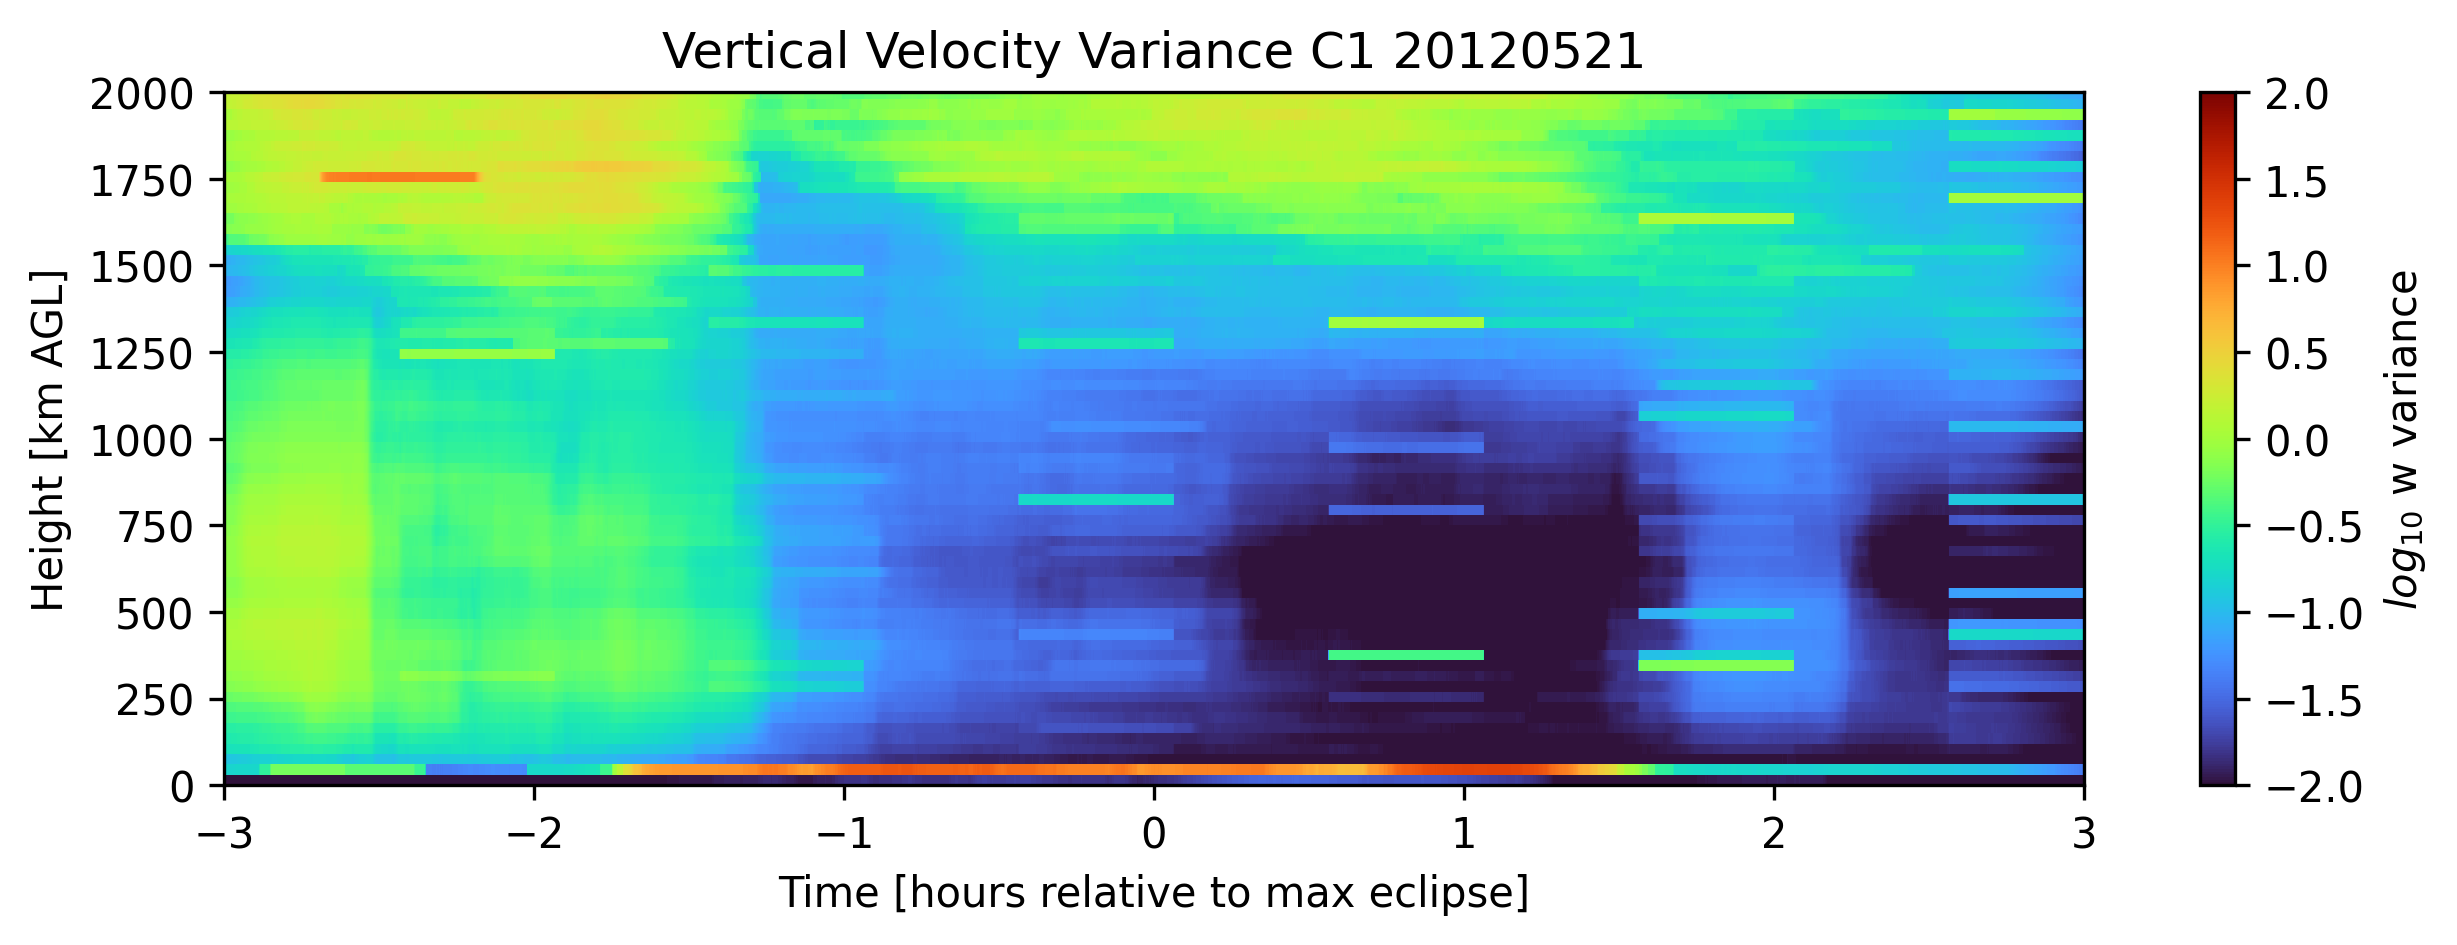

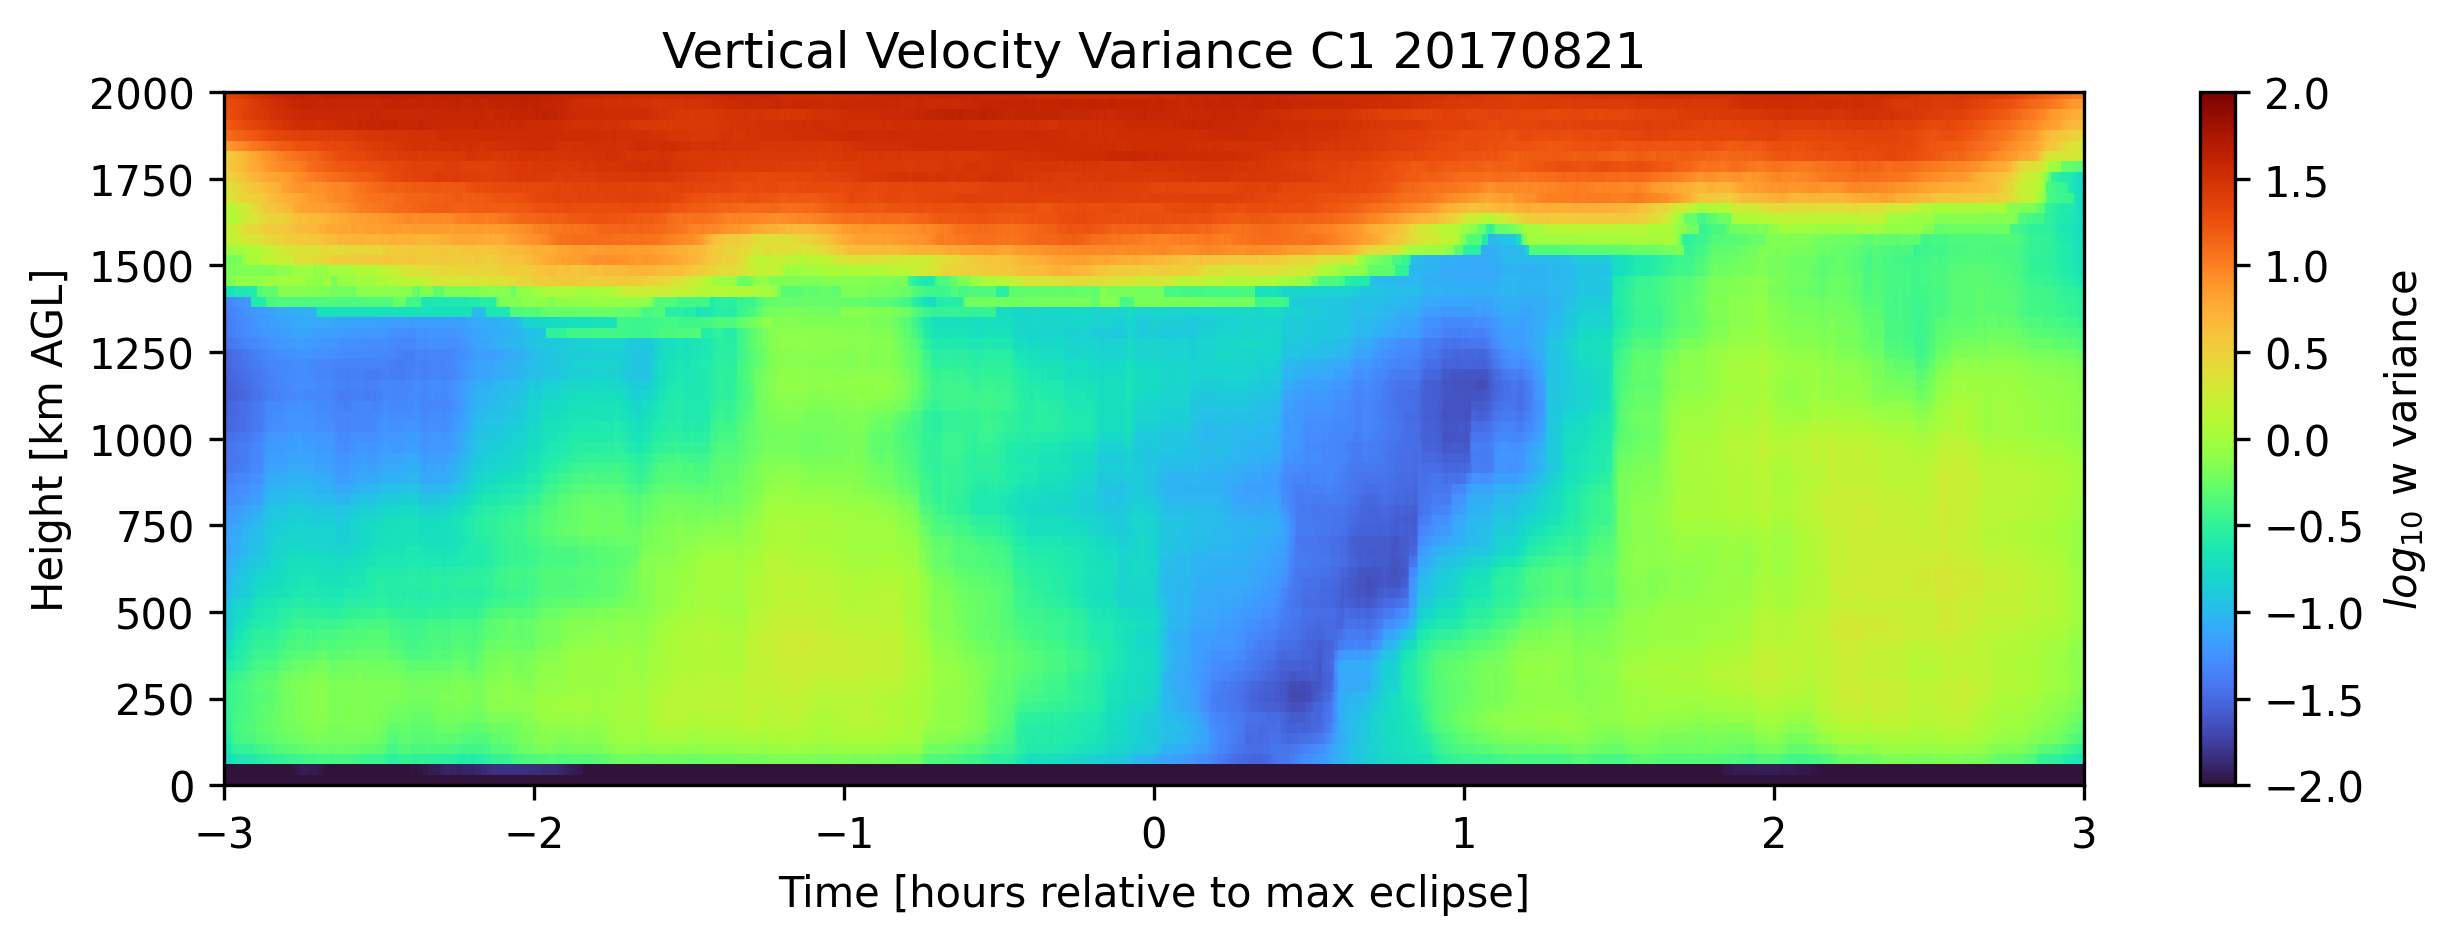

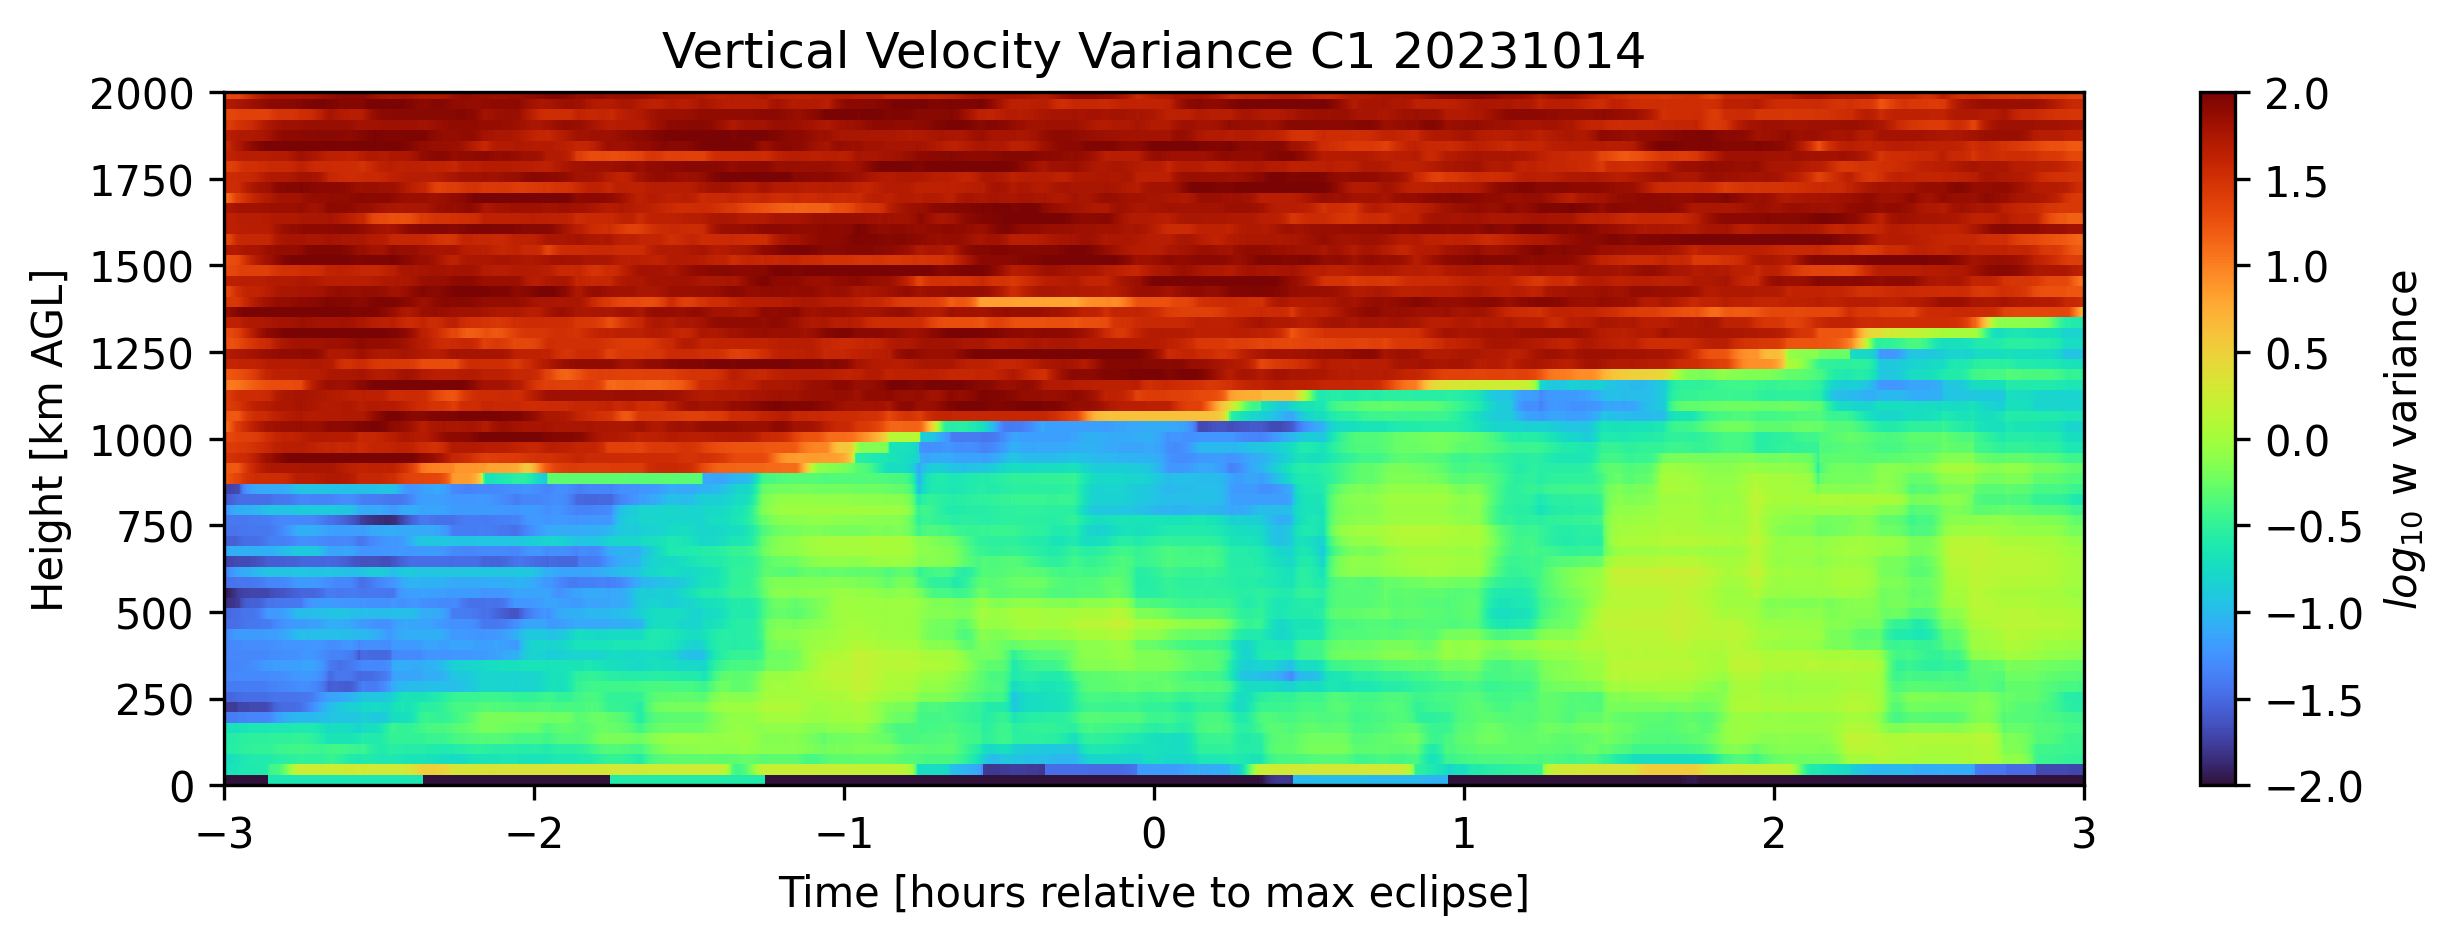

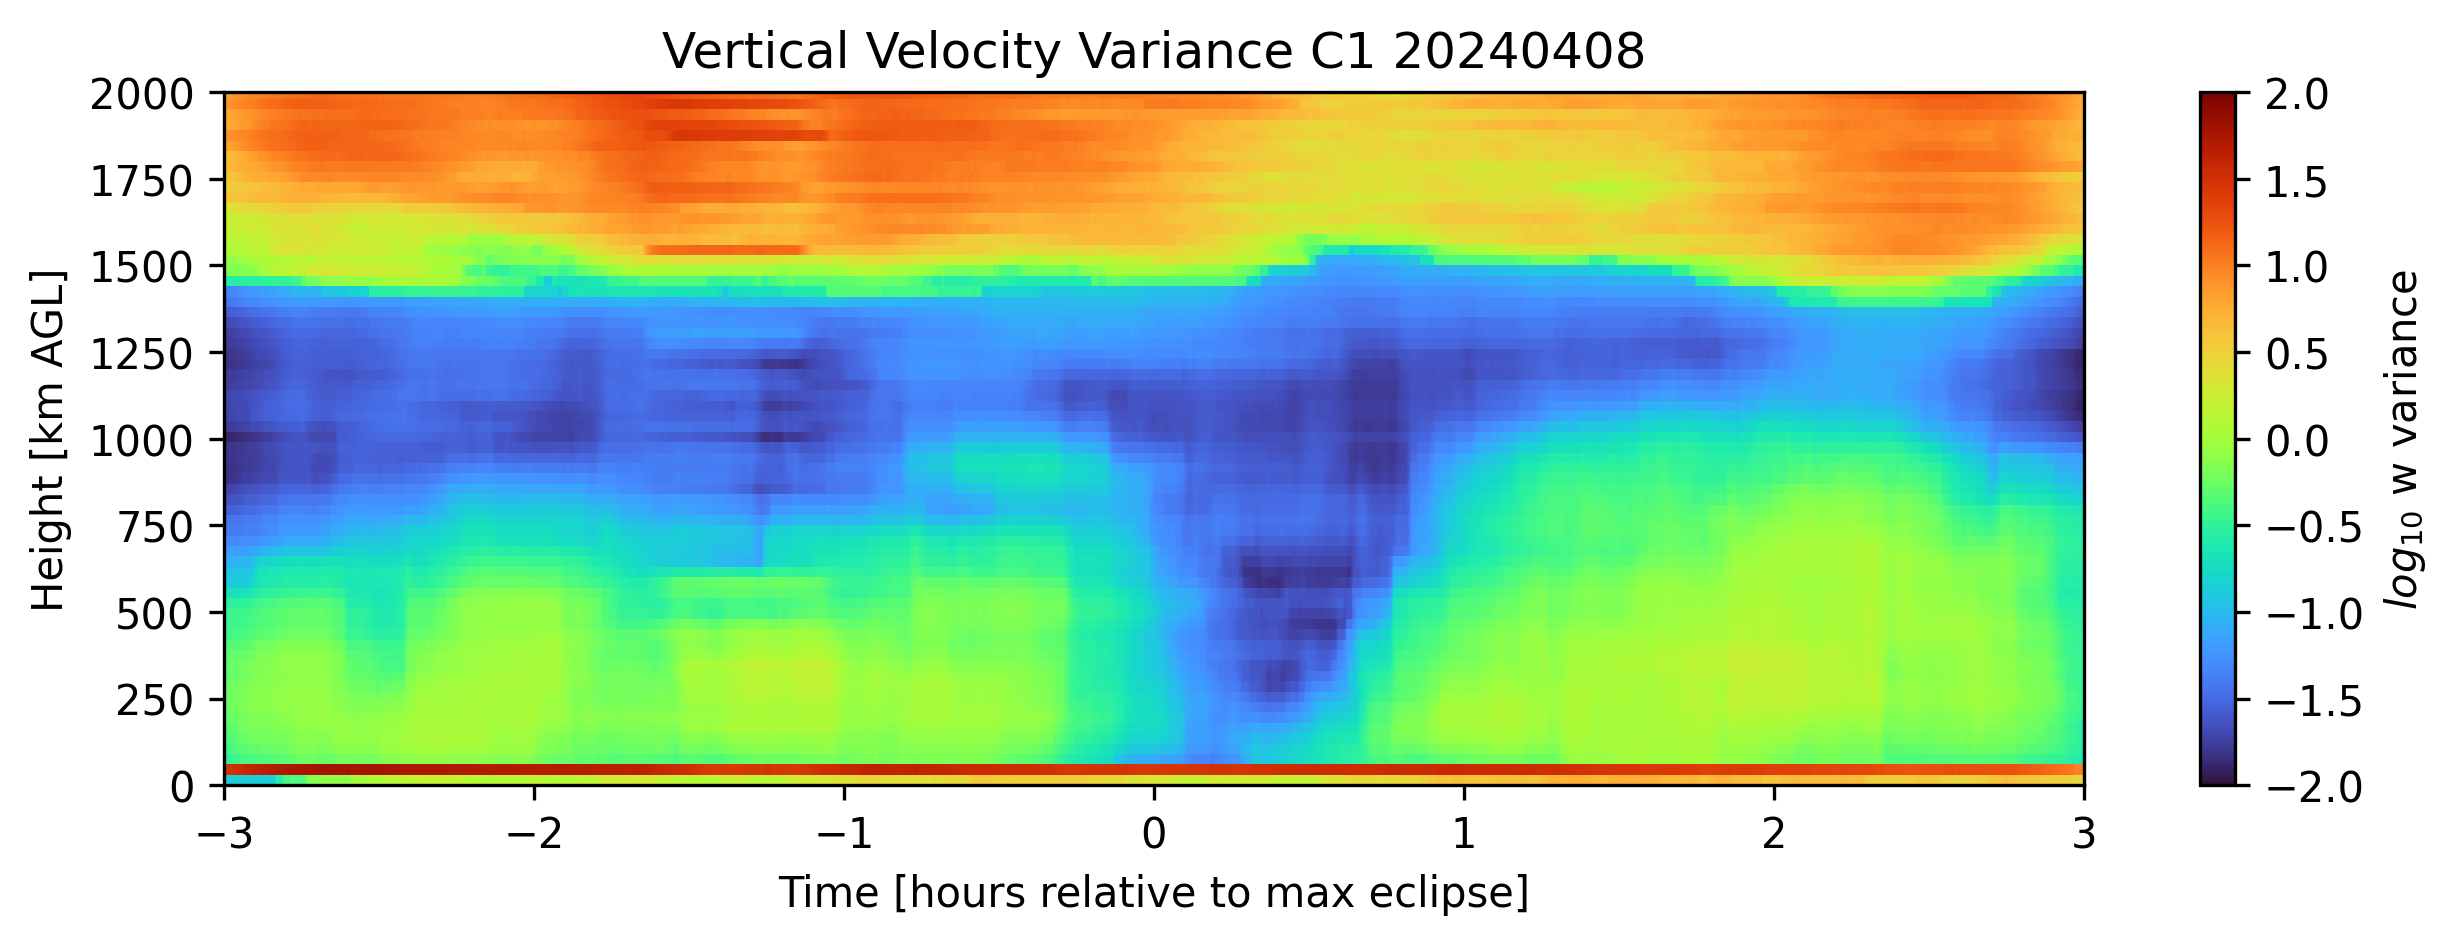

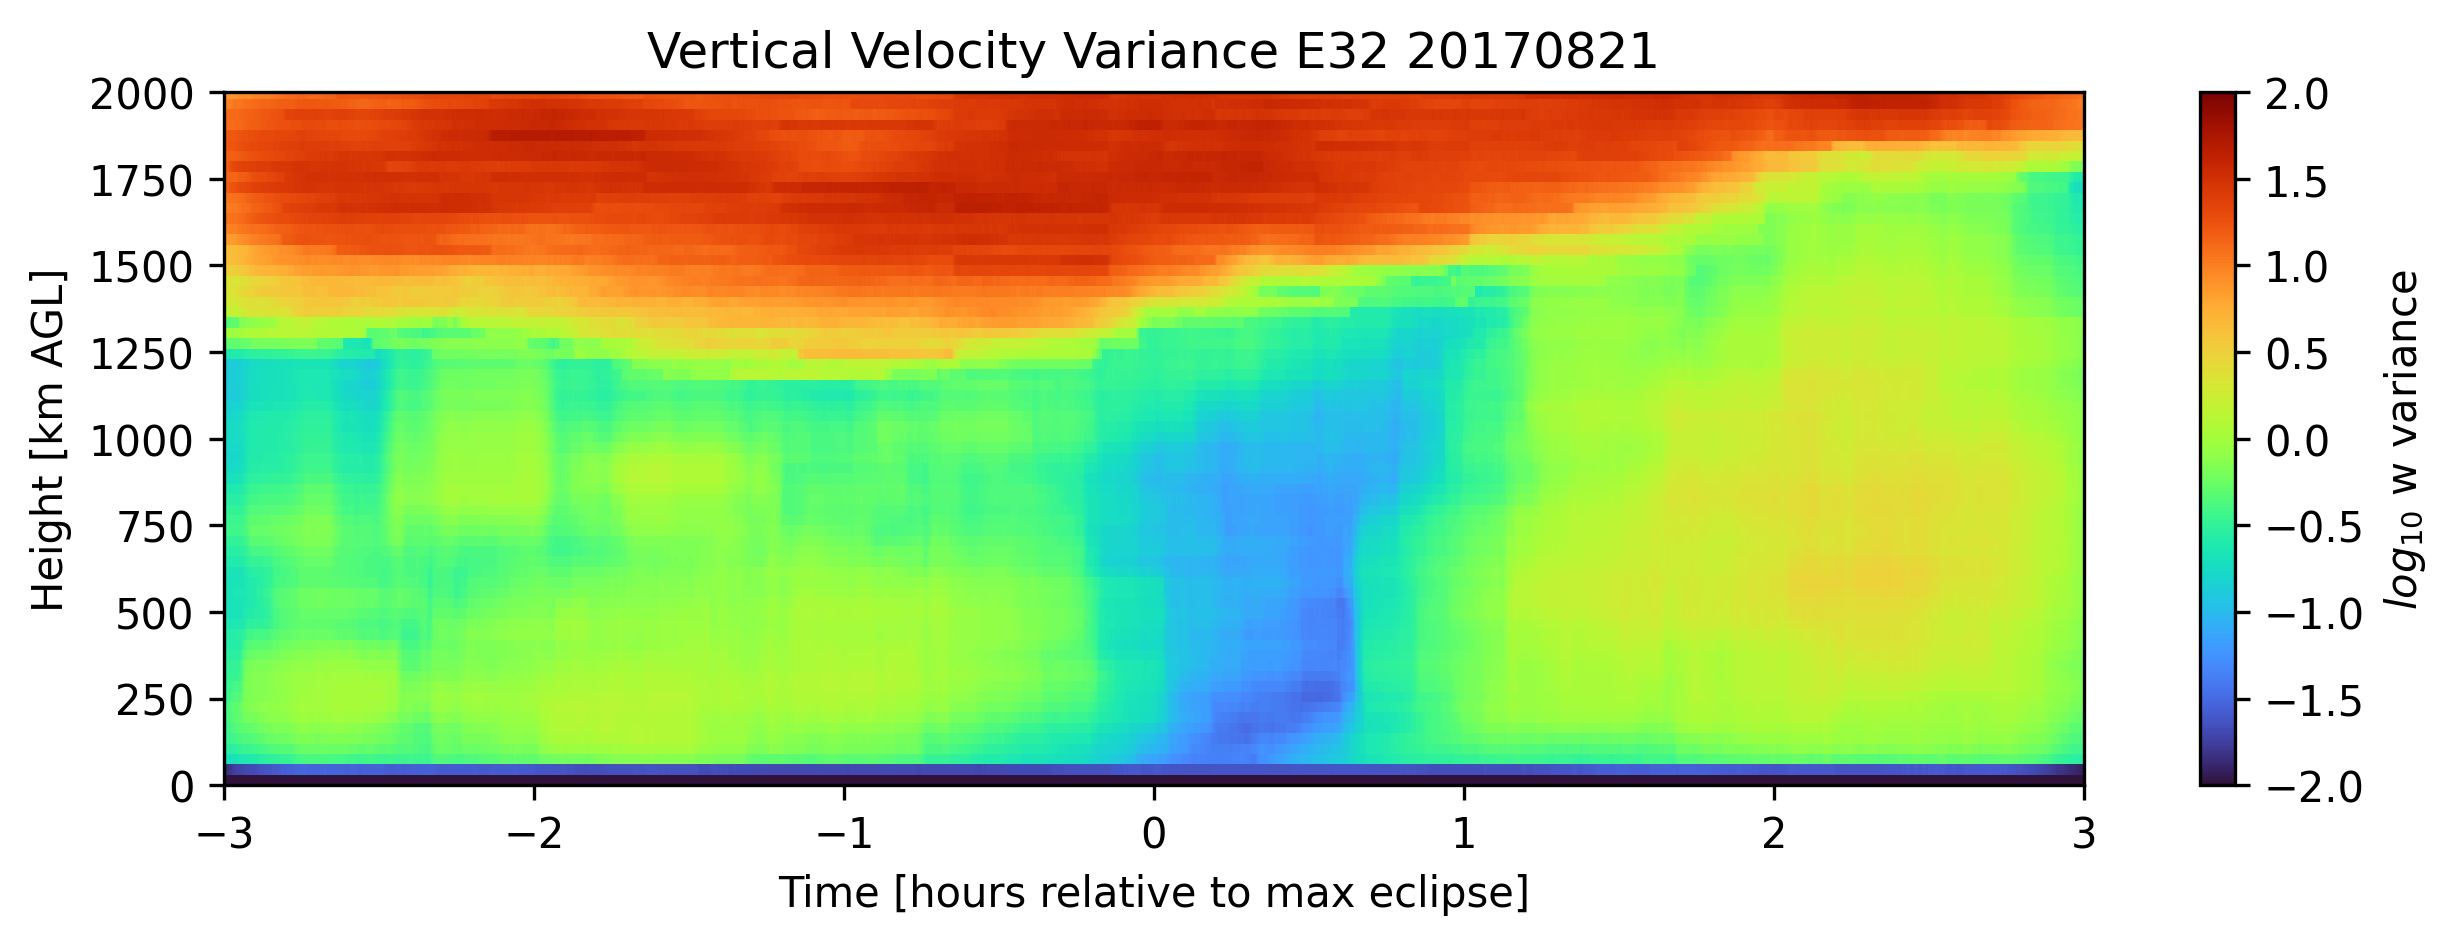

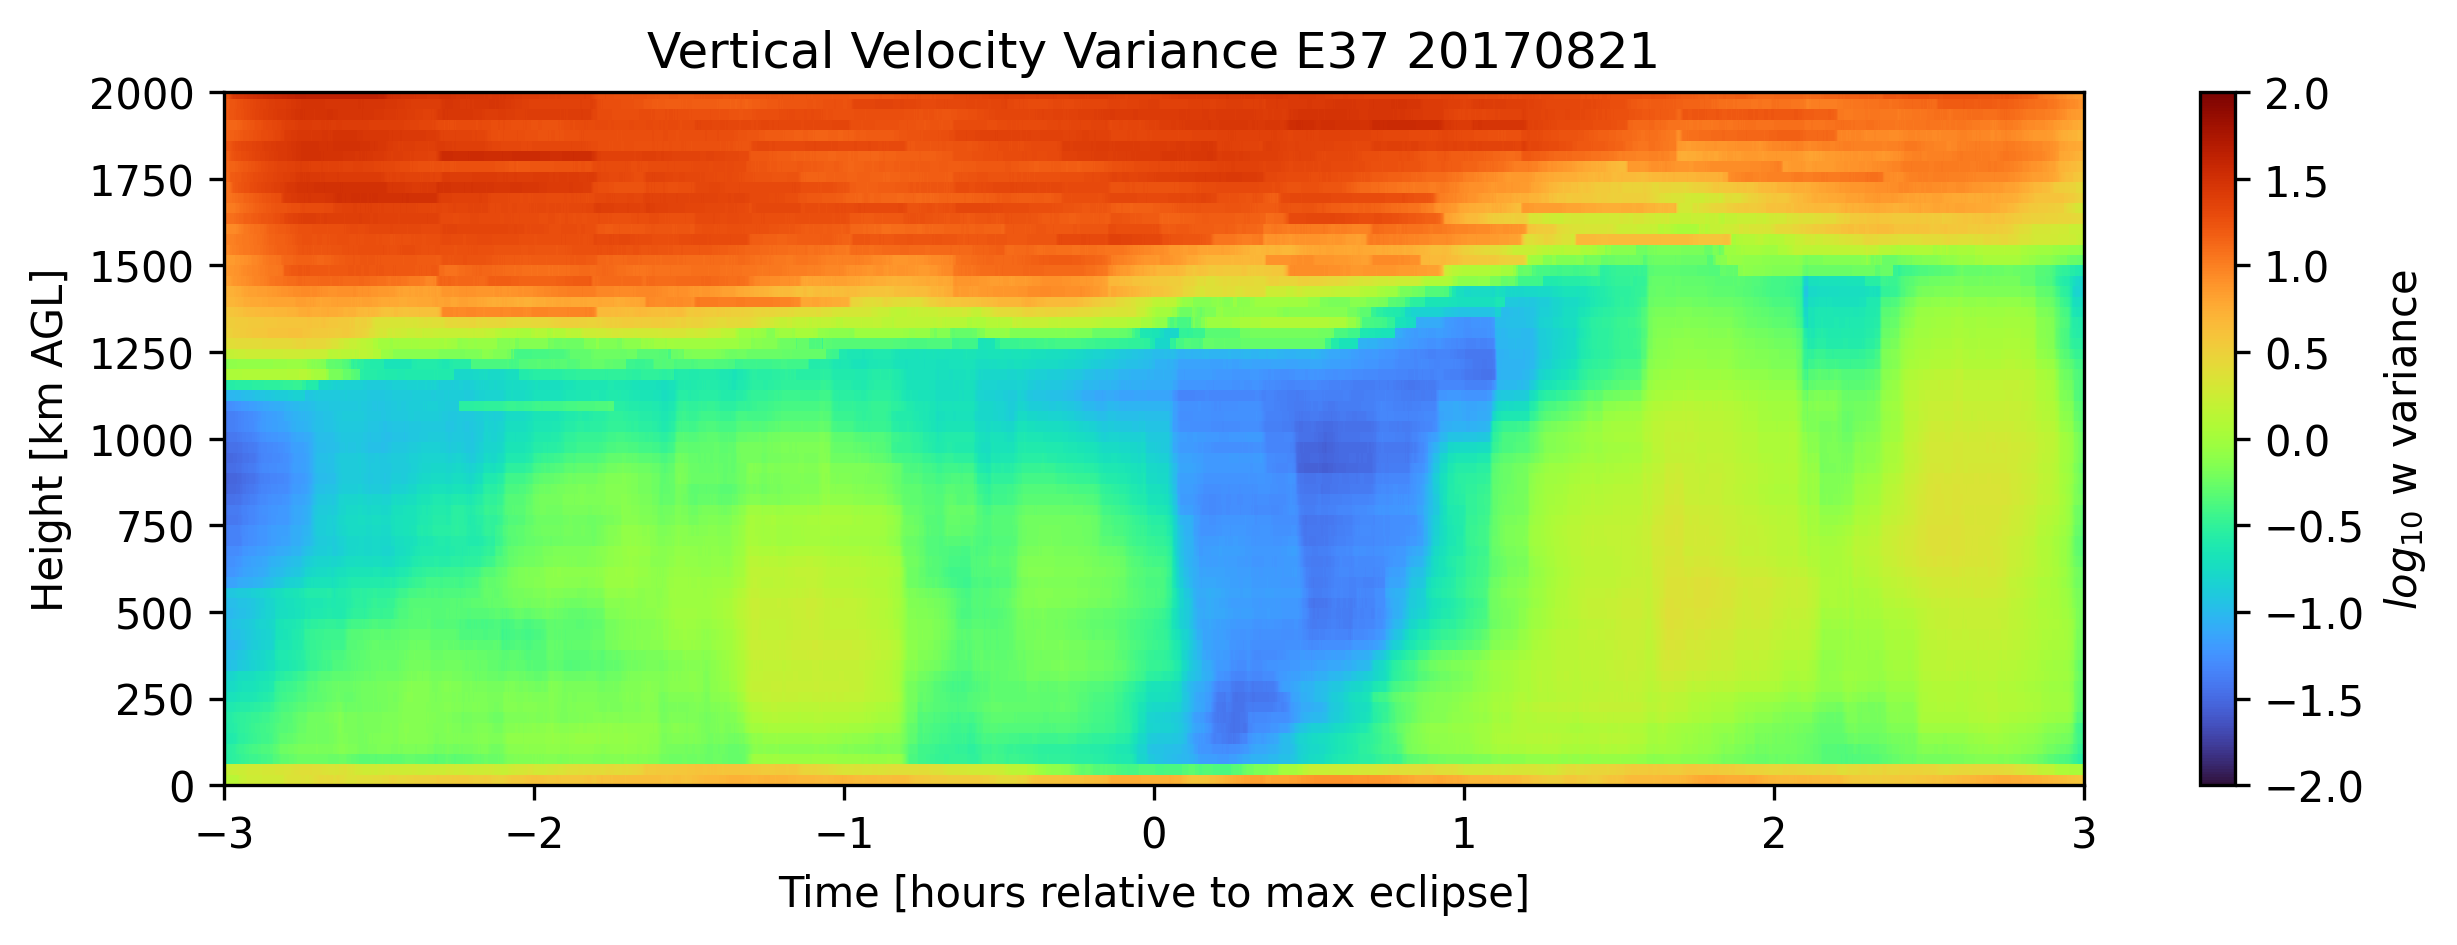

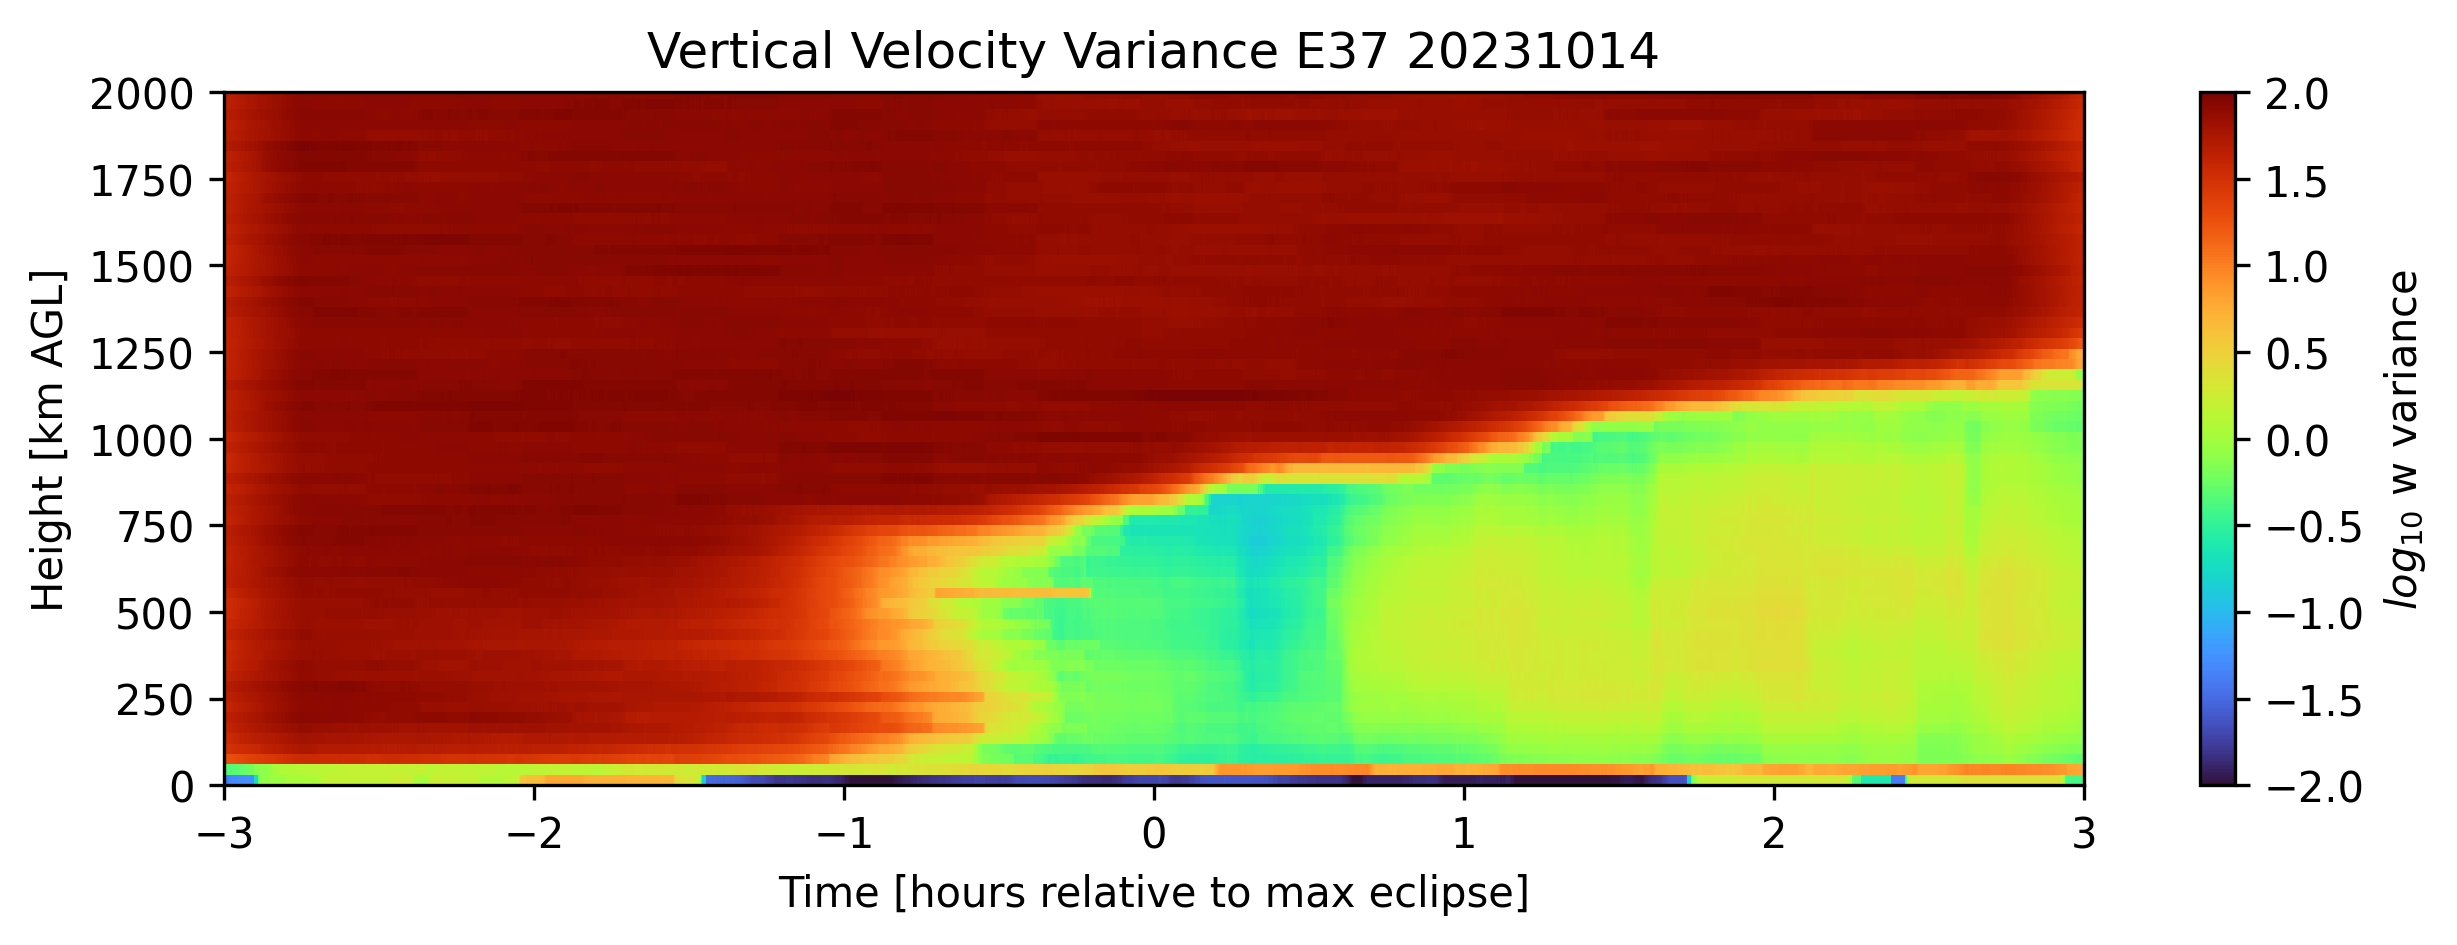

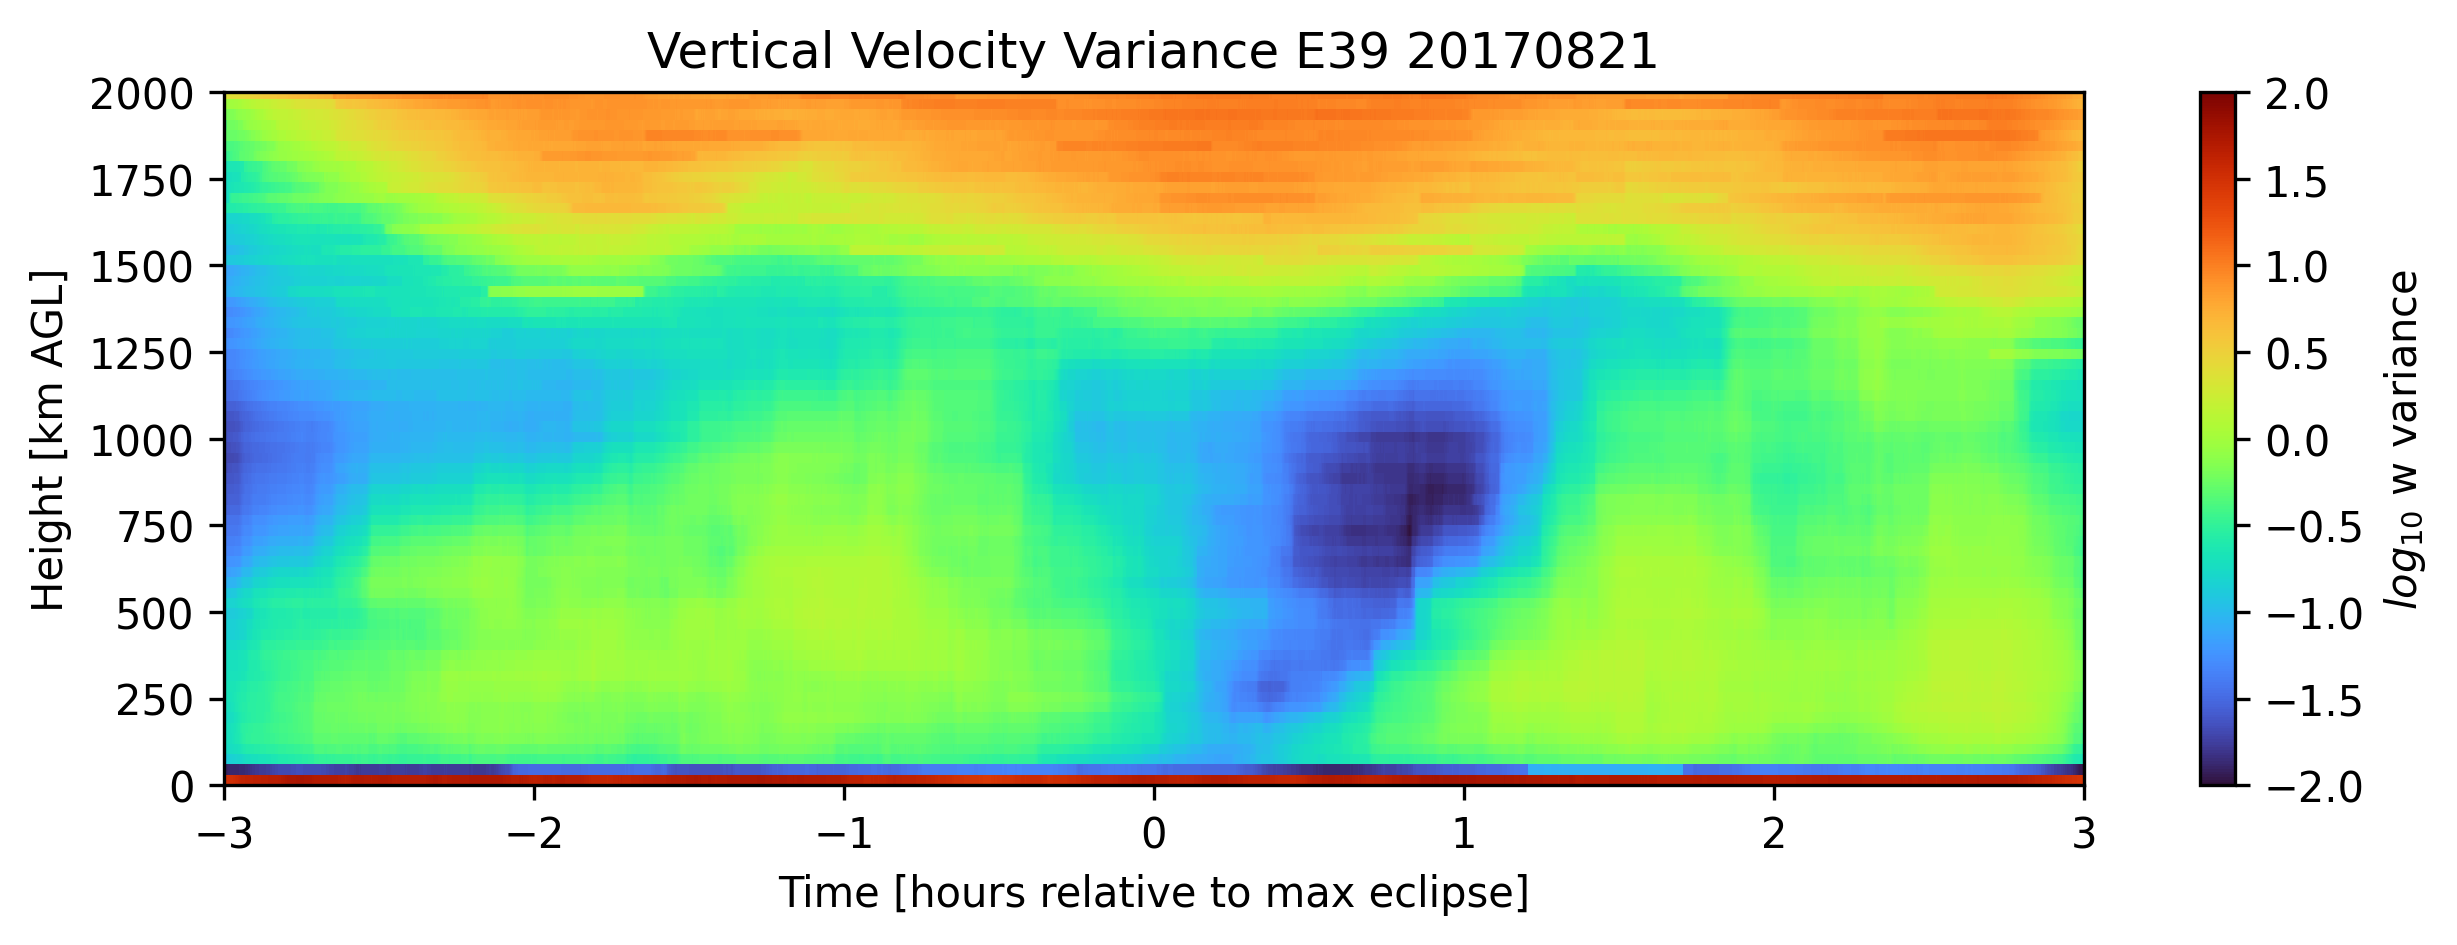

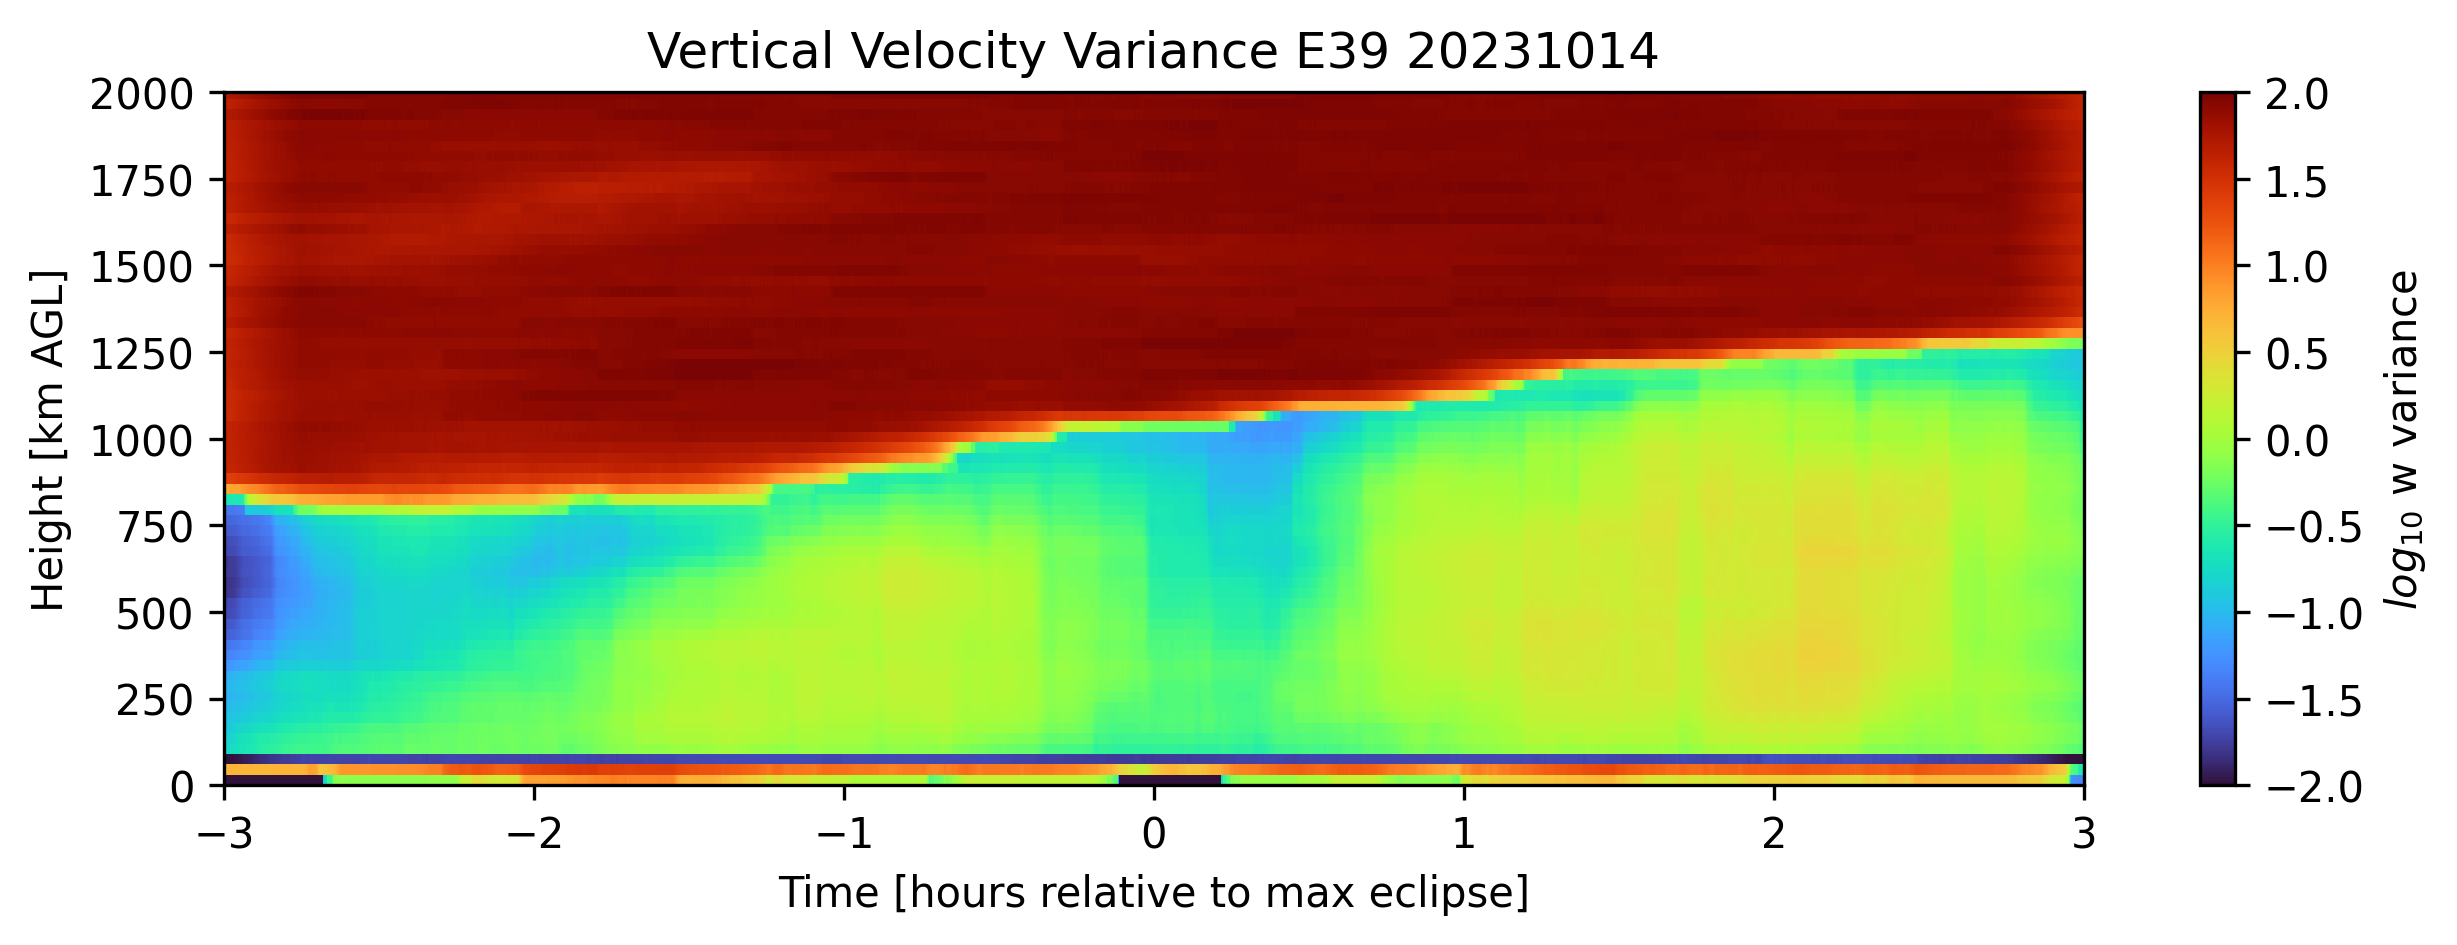

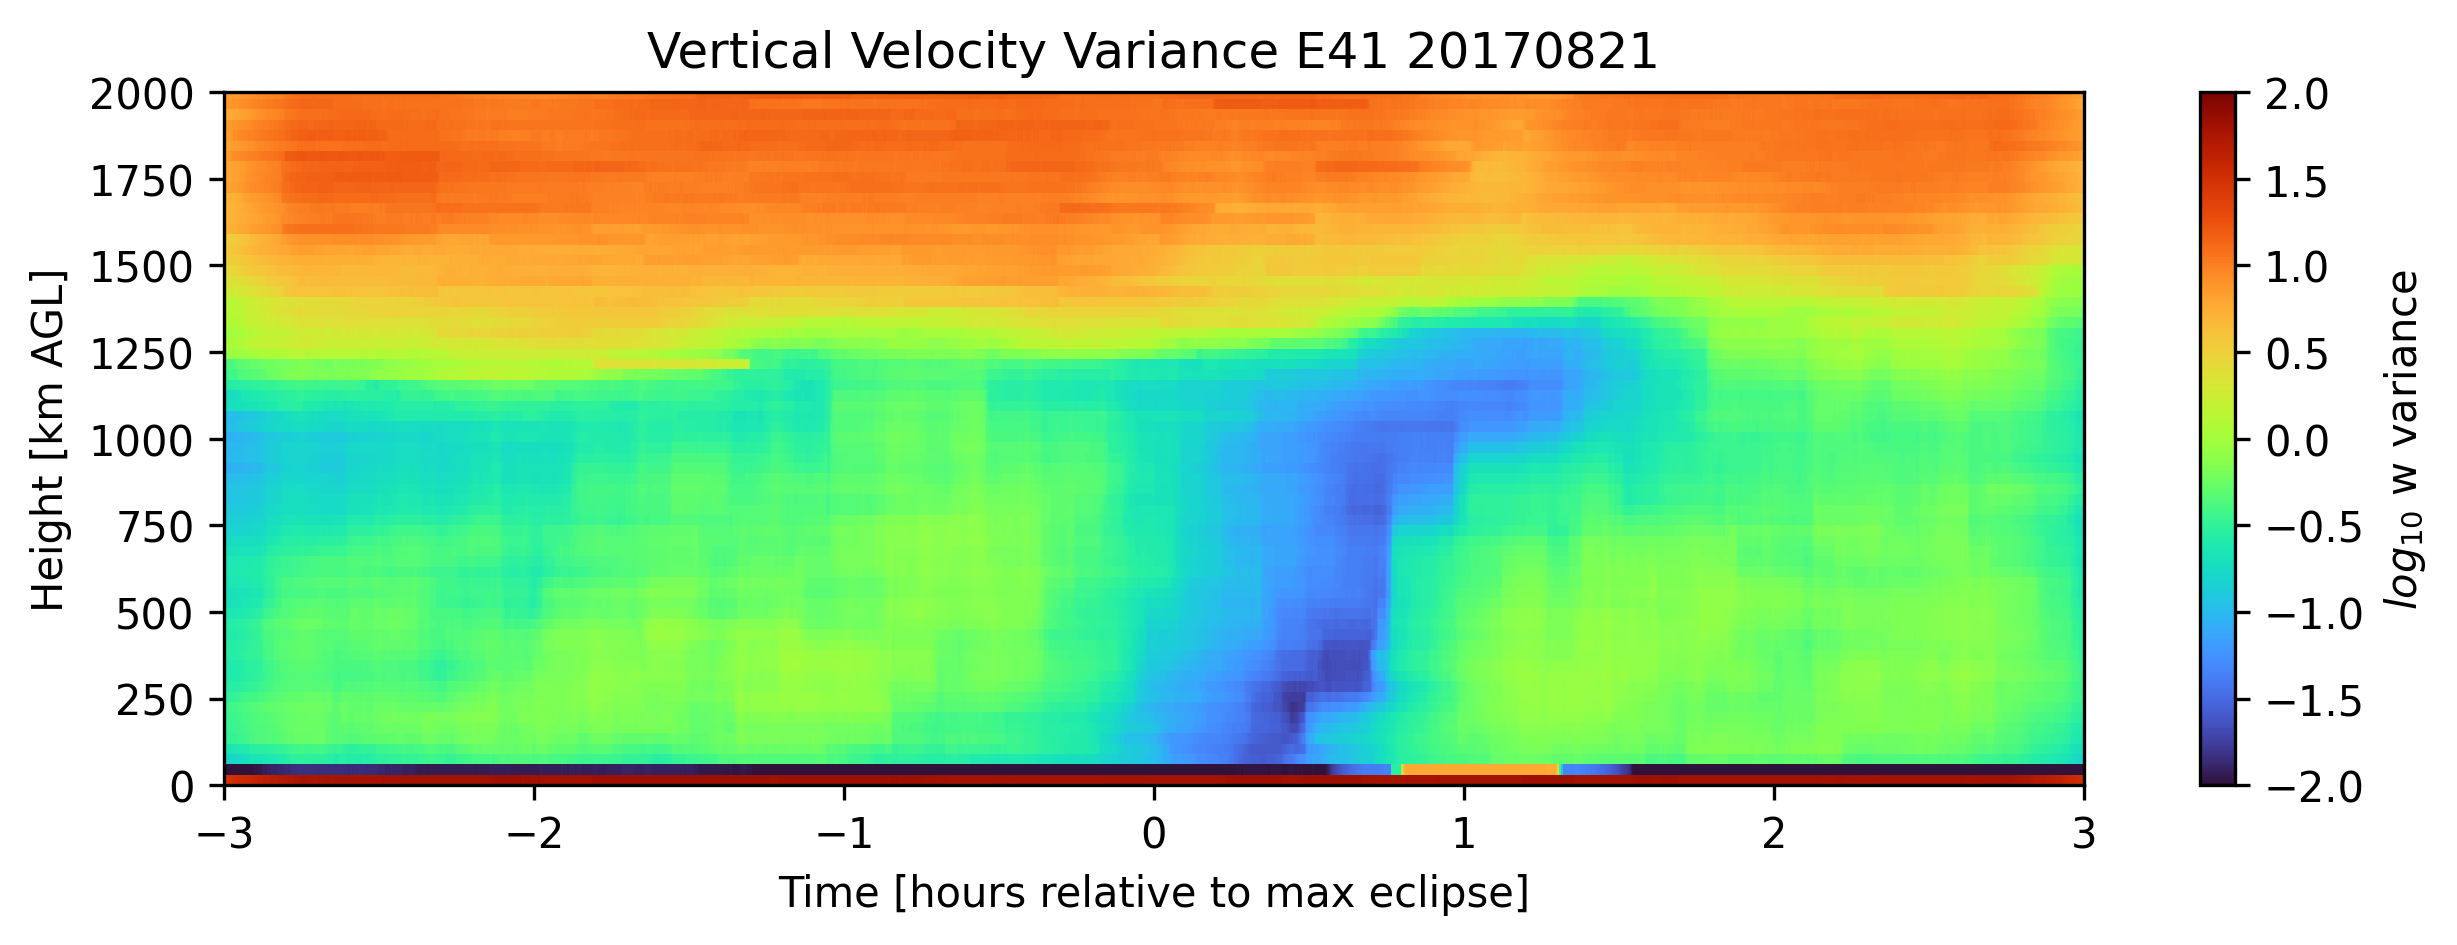

In [5]:
ctr = 0

for g in np.arange(len(eclipseSites)):


    for h in np.arange(len(eclipseDates)):
        
        

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
            
            dl.time = dl.time - eclipseTimes[h]

        except:
            
            ctr=ctr+1
            continue
        
        interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

        wNew = interpFunc(timeNew, heightNew)


        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)

        for i in range(totalStartIdx, totalEndIdx):
    
       
            meanW = np.mean(wNew[i-900:i+900,:],axis=0)
            wPrime[i,:] = wNew[i,:]-meanW

        for i in range(totalStartIdx, totalEndIdx):

            wVar[i,:,ctr] = np.var(wPrime[i-900:i+900,:],axis=0)


        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        cbar = plt.colorbar()
        cbar.set_label('$log_{10}$ w variance')
        plt.title('Vertical Velocity Variance ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        plt.xlabel('Time [hours relative to max eclipse]')
        plt.ylabel('Height [km AGL]')
        plt.show()

        saveDate[ctr] = eclipseDates[h]
        ctr = ctr+1


Let's make some collective figures now shoeing mean behavior across the various sites for a single event.

/var/folders/sc/bkdnv16d7vbgn44gdn17nmr40000gn/T/ipykernel_88424/3720521663.py:3: RuntimeWarning: divide by zero encountered in log10
  meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)


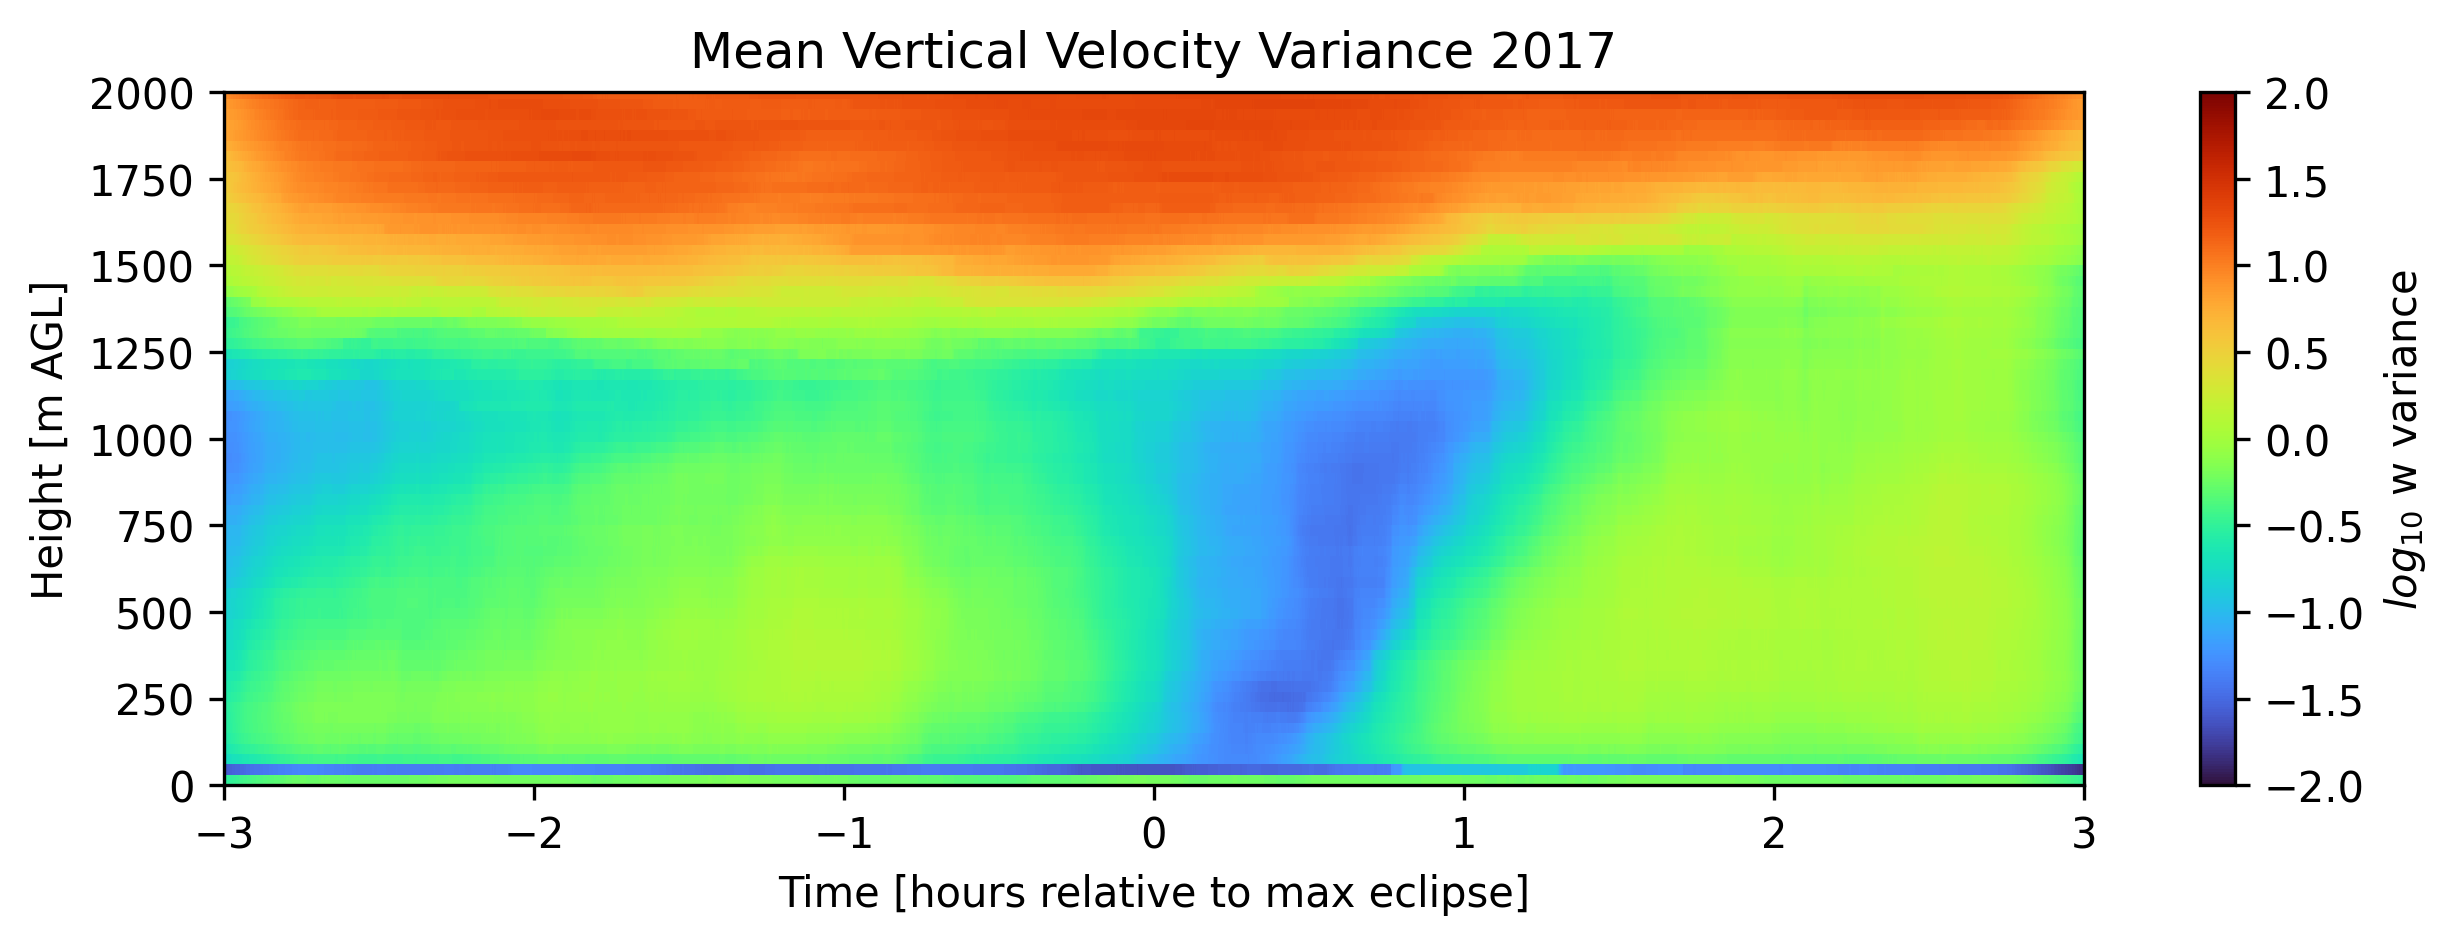

/var/folders/sc/bkdnv16d7vbgn44gdn17nmr40000gn/T/ipykernel_88424/3720521663.py:21: RuntimeWarning: divide by zero encountered in log10
  meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)


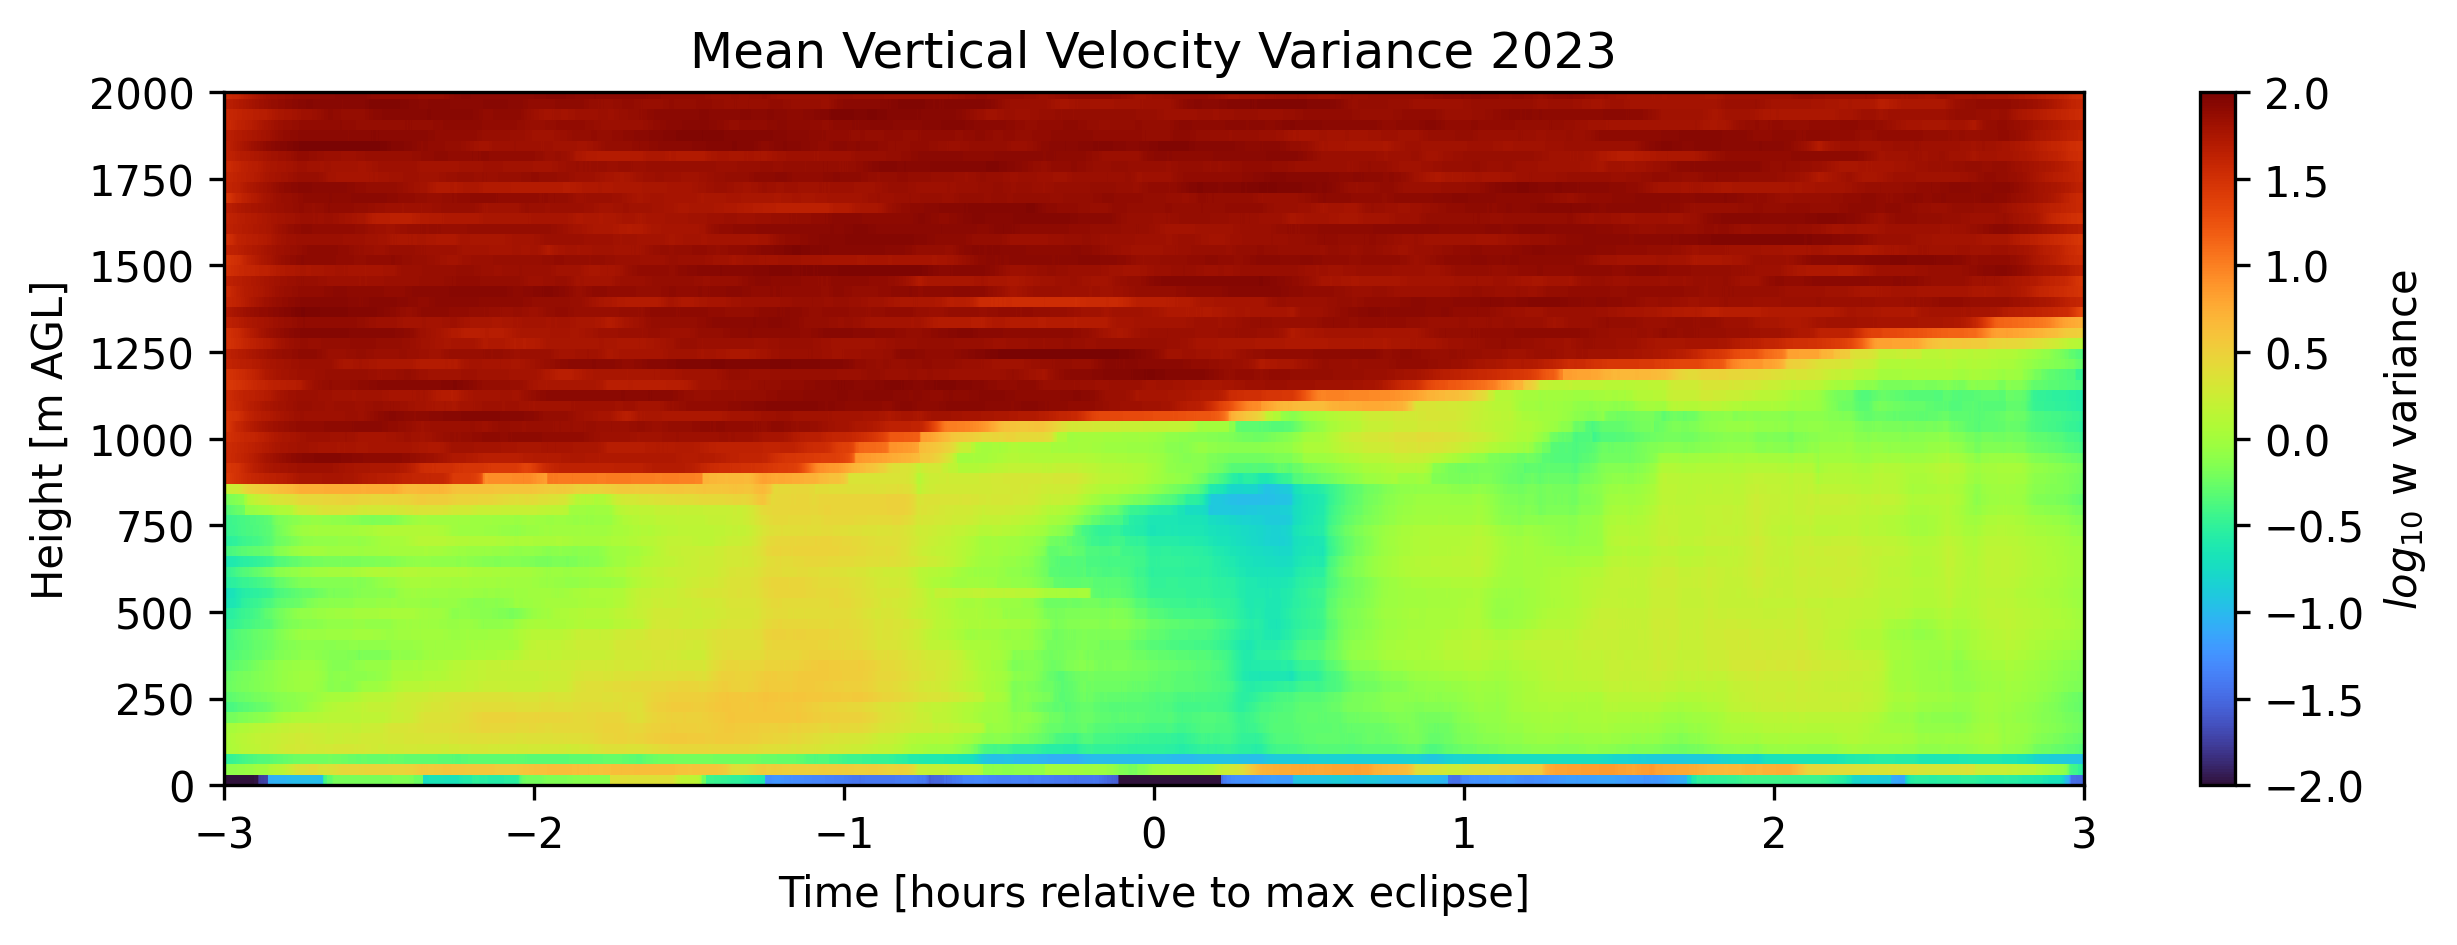

/var/folders/sc/bkdnv16d7vbgn44gdn17nmr40000gn/T/ipykernel_88424/3720521663.py:38: RuntimeWarning: divide by zero encountered in log10
  meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)


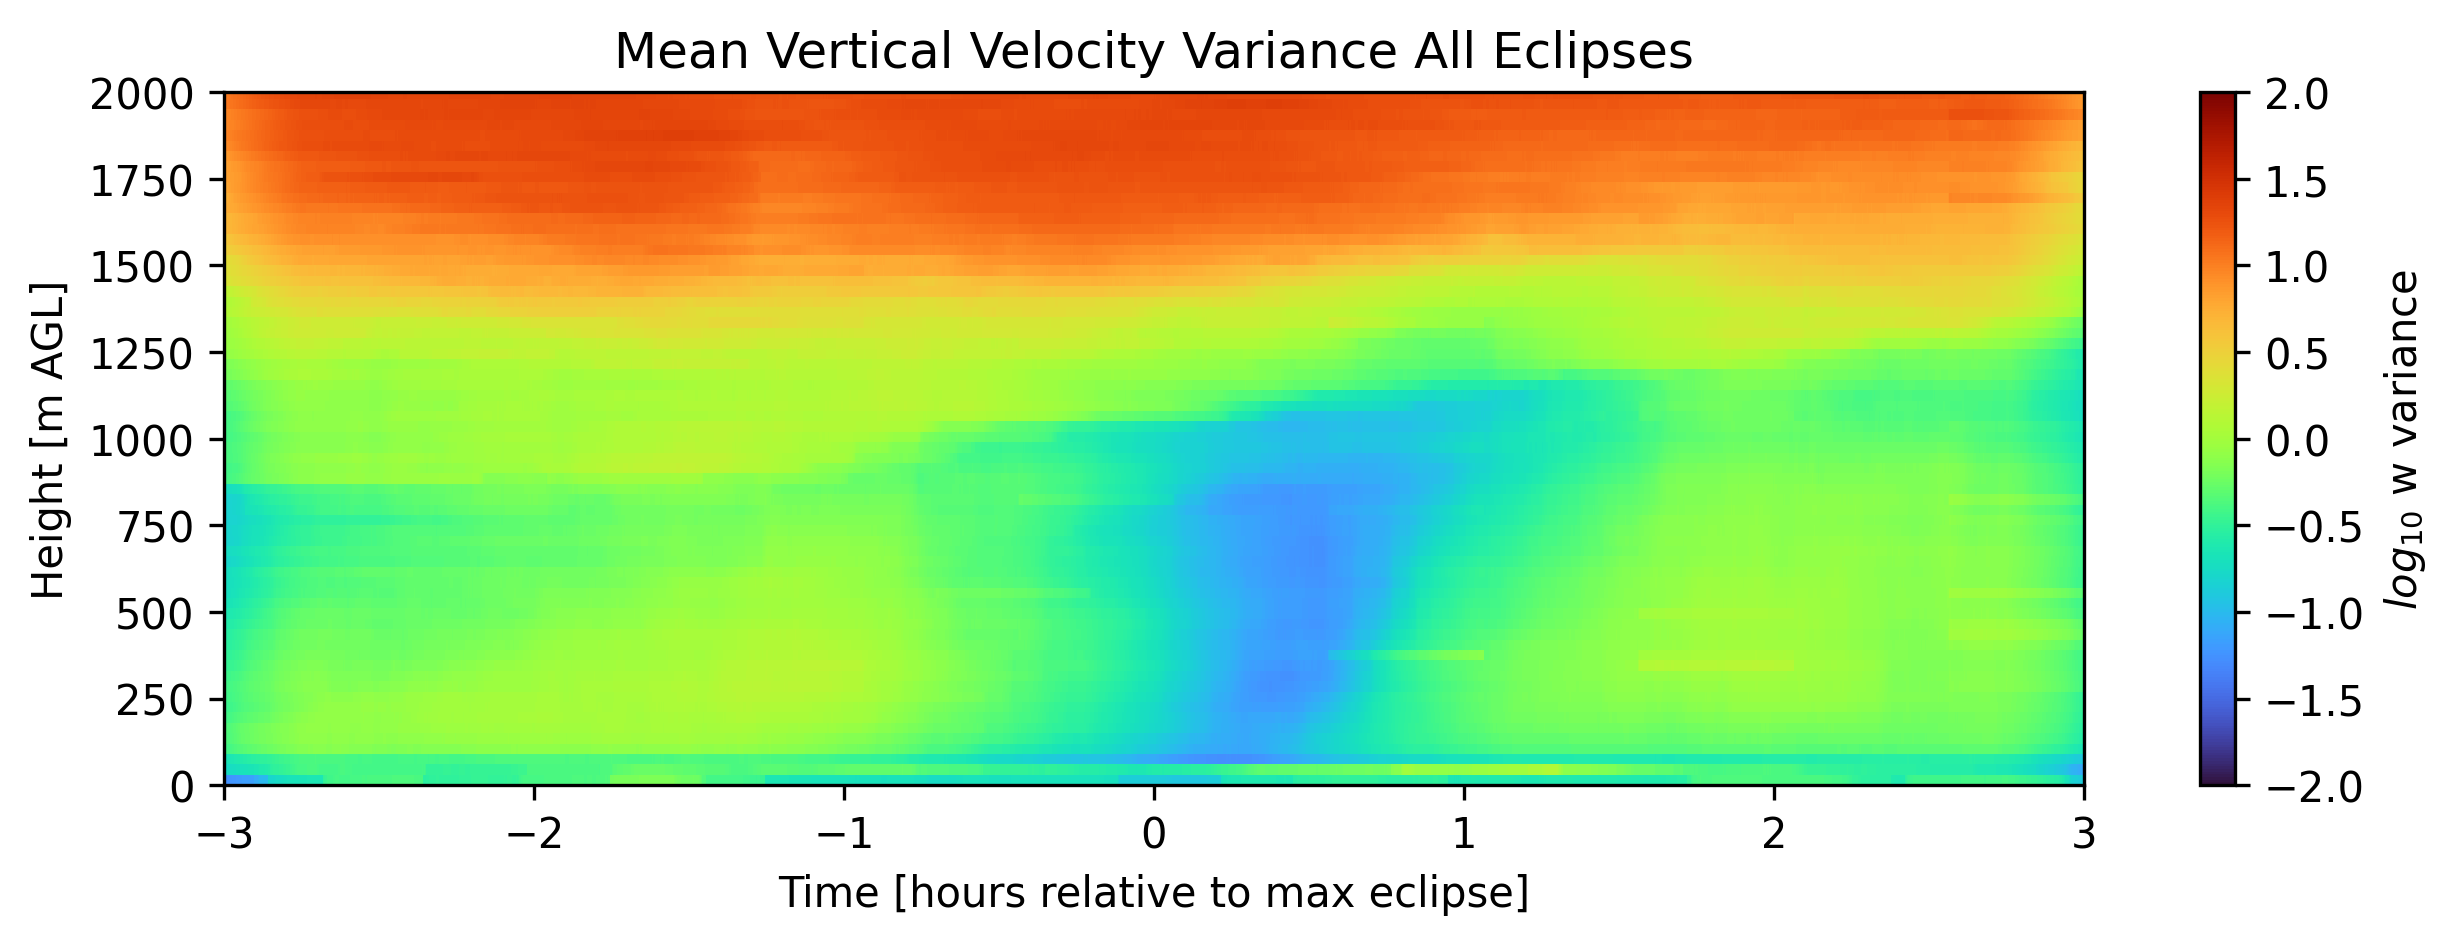

In [6]:
idx = np.where(saveDate ==20170821)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance 2017')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.show()



idx = np.where(saveDate ==20231014)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance 2023')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.show()


idx = np.where(saveDate > 2000)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ w variance')
plt.title('Mean Vertical Velocity Variance All Eclipses')
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.show()

### PBL-normalized height grid

Now, do what we've done before, but this time do it with the grid normalized to the pbl heights using Julia's code.

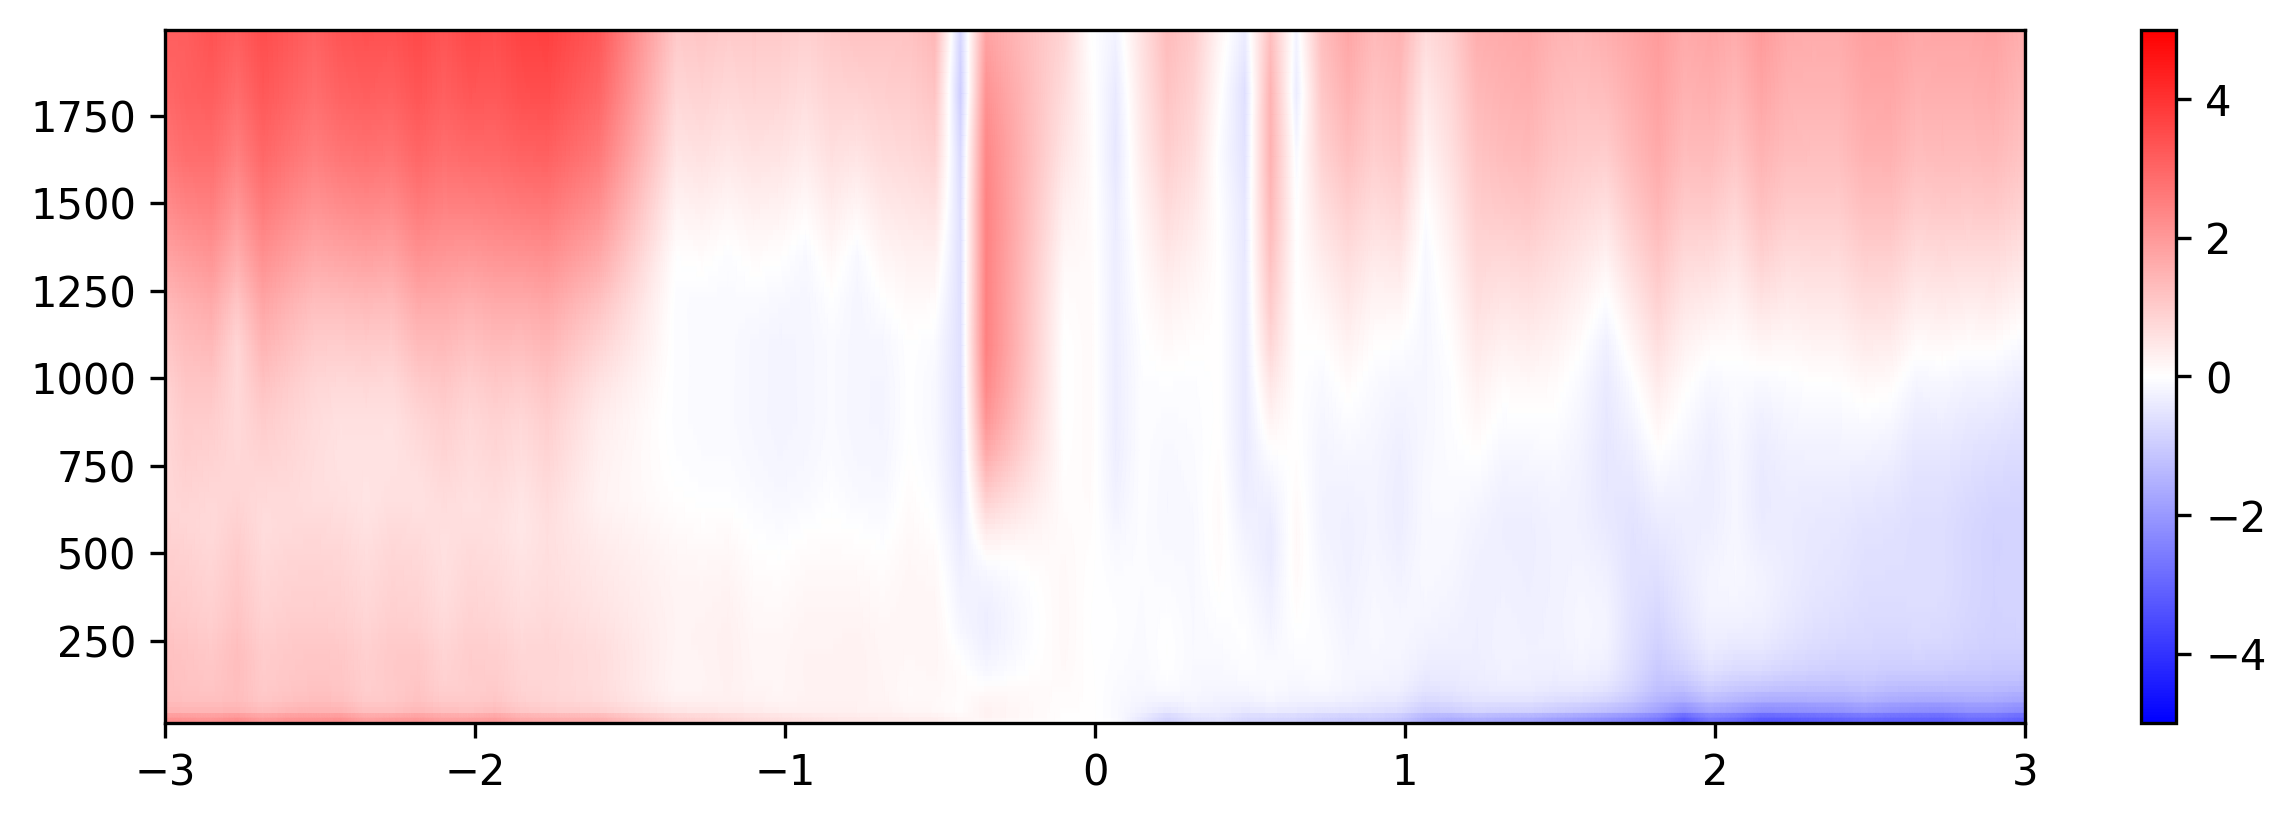

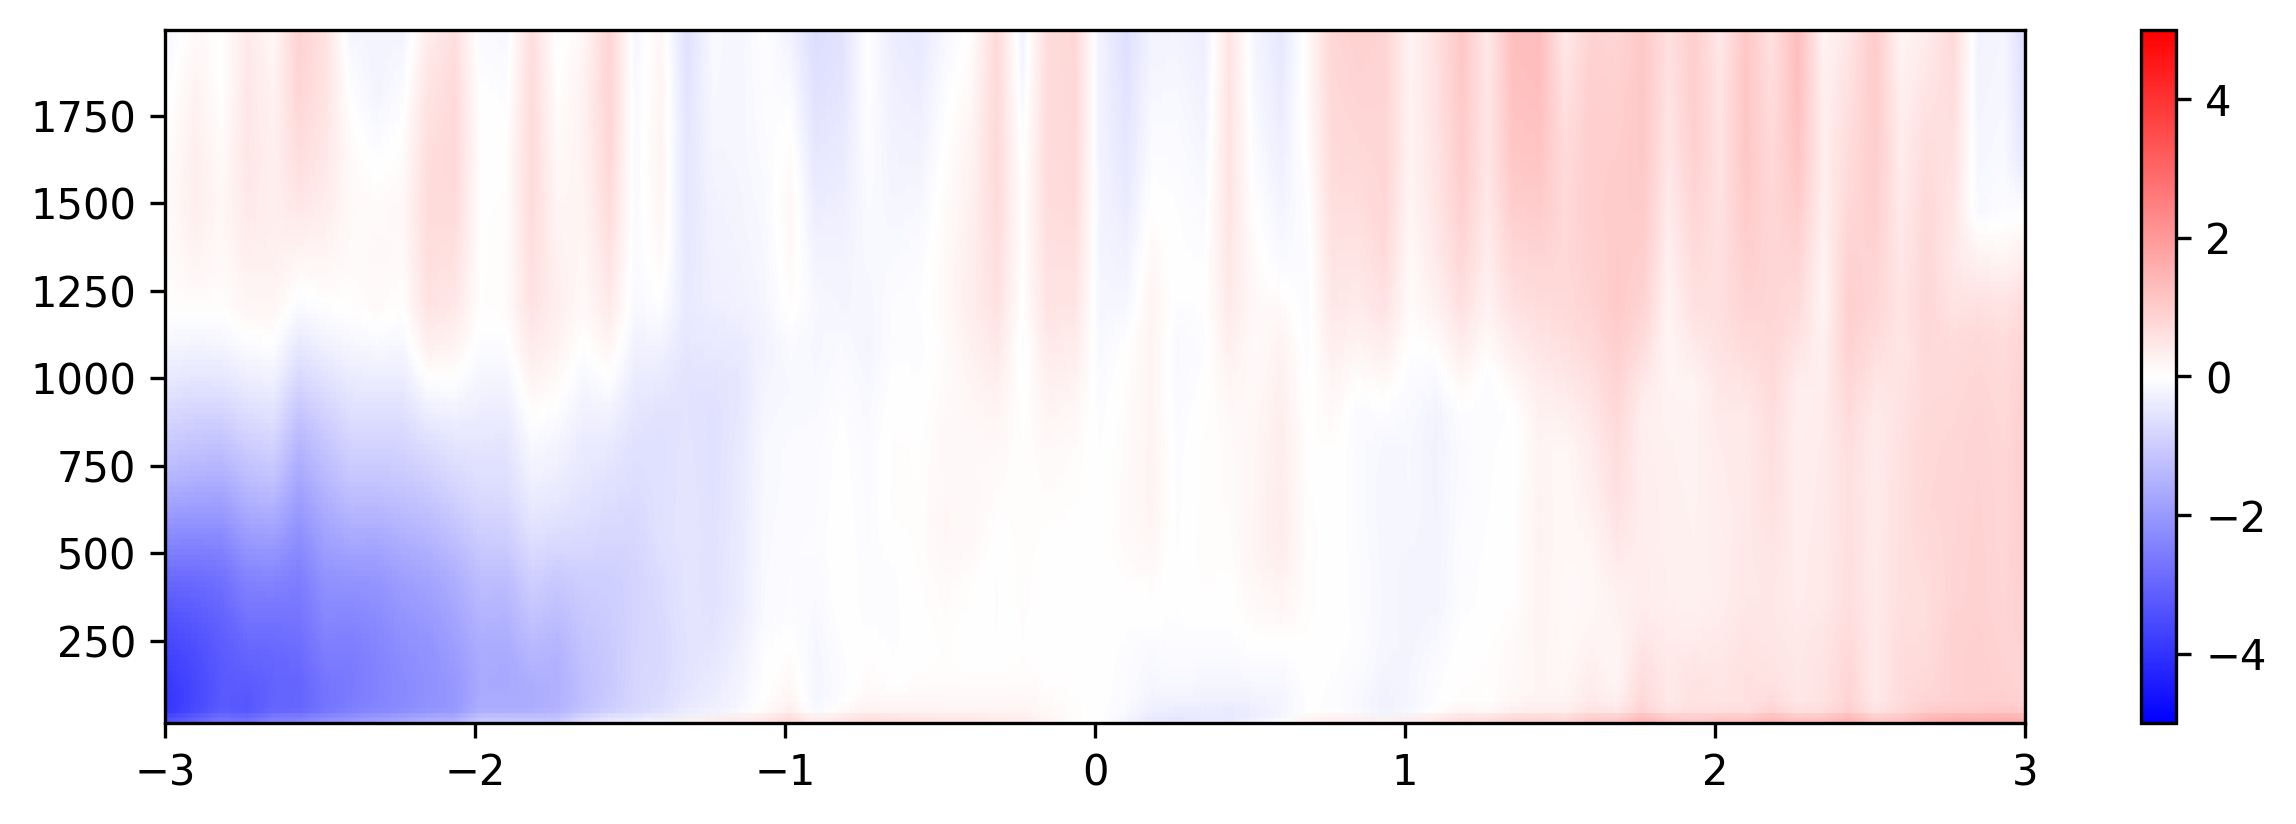

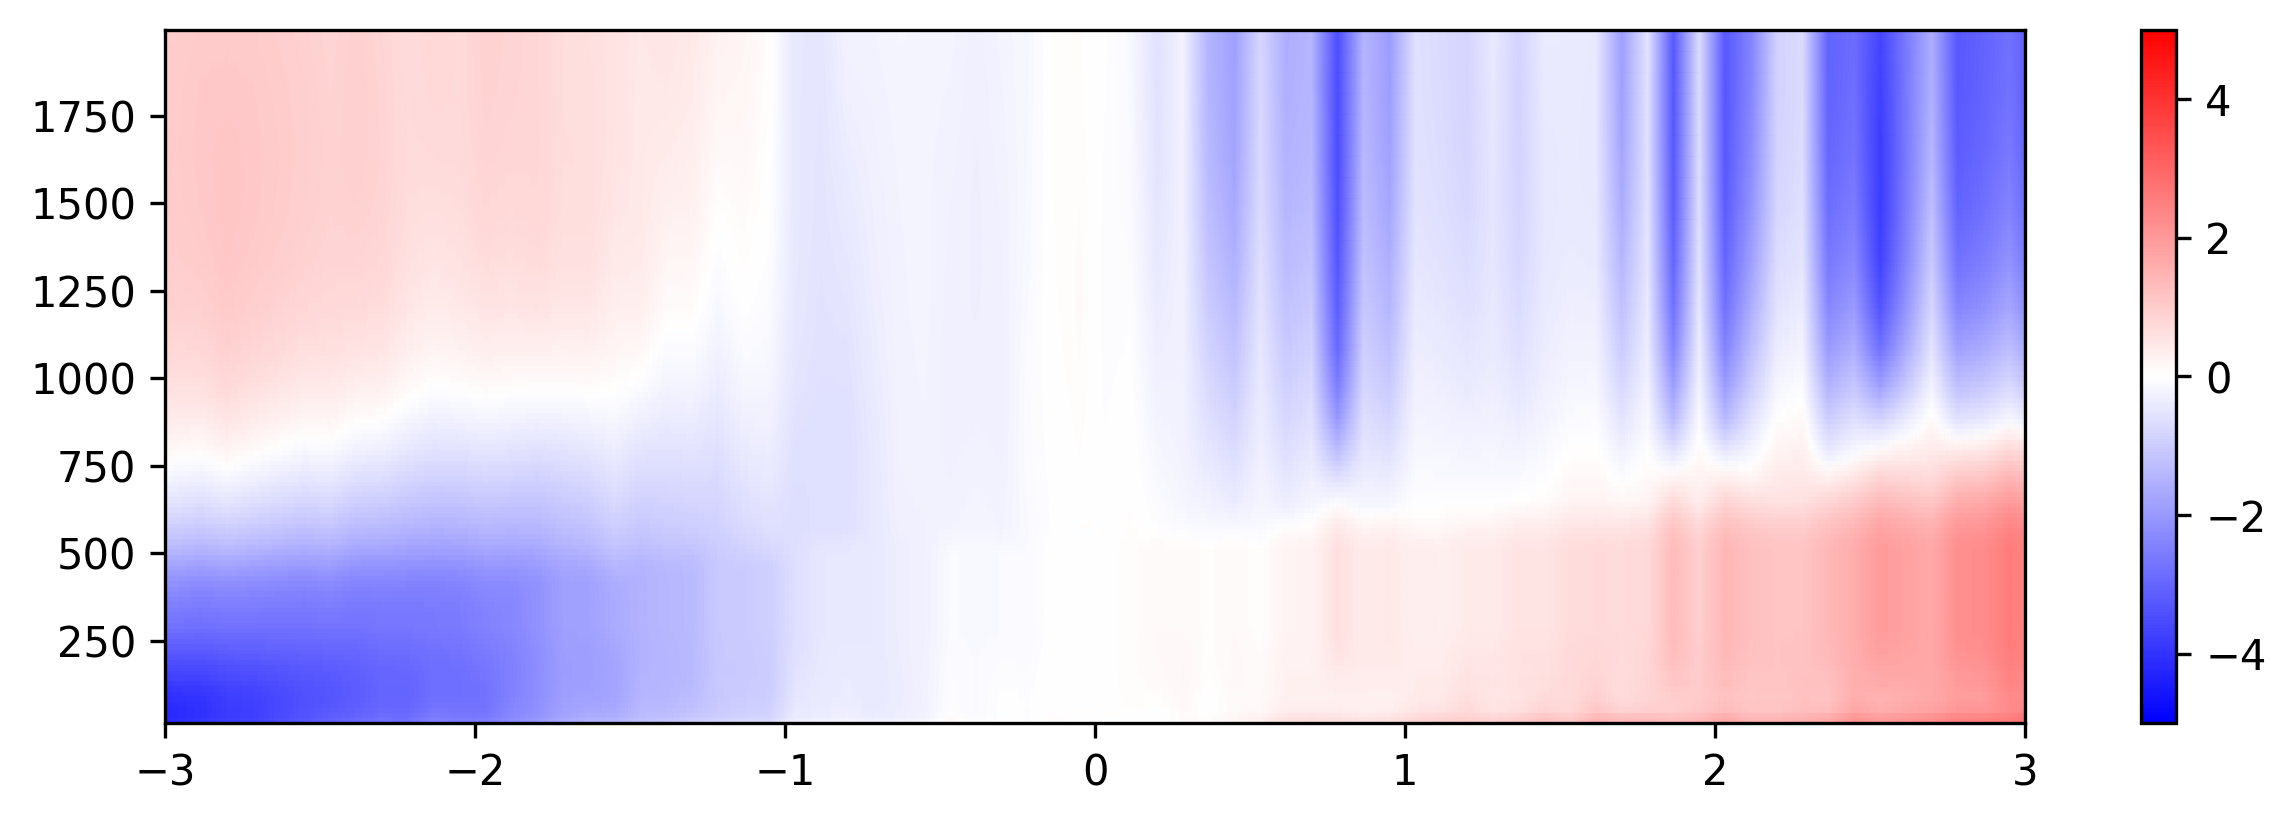

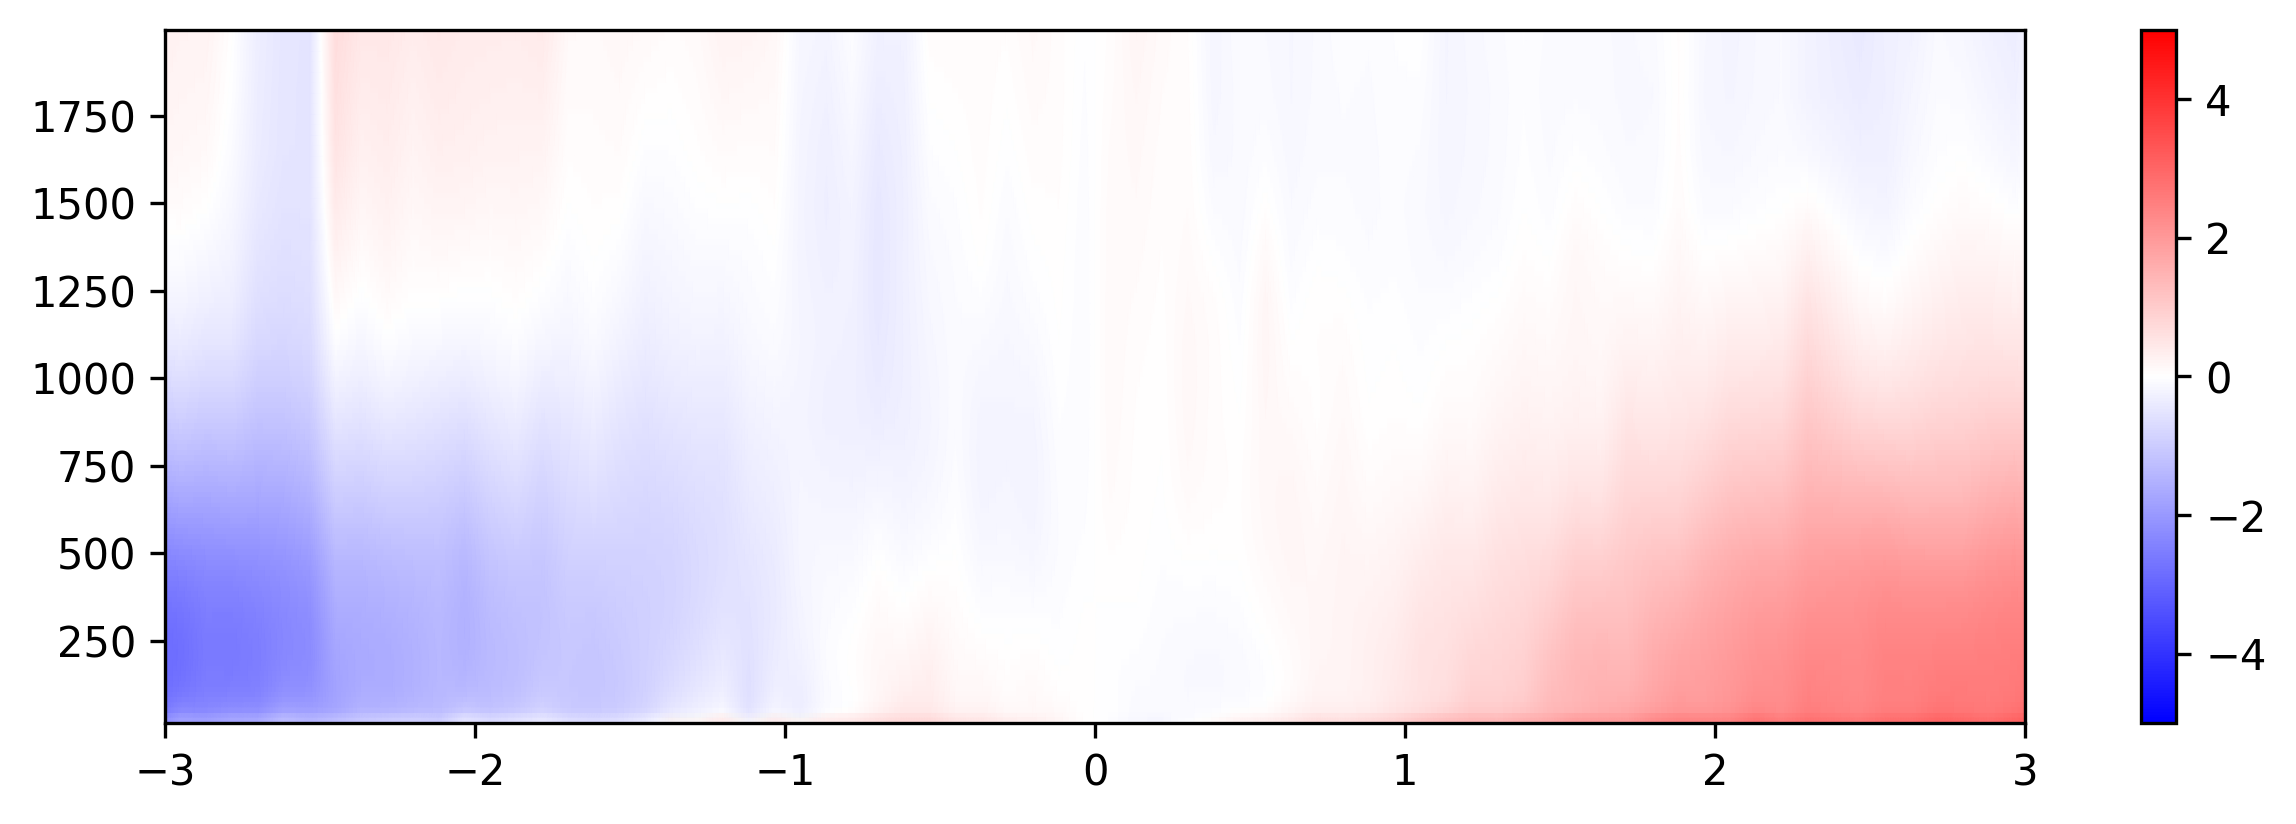

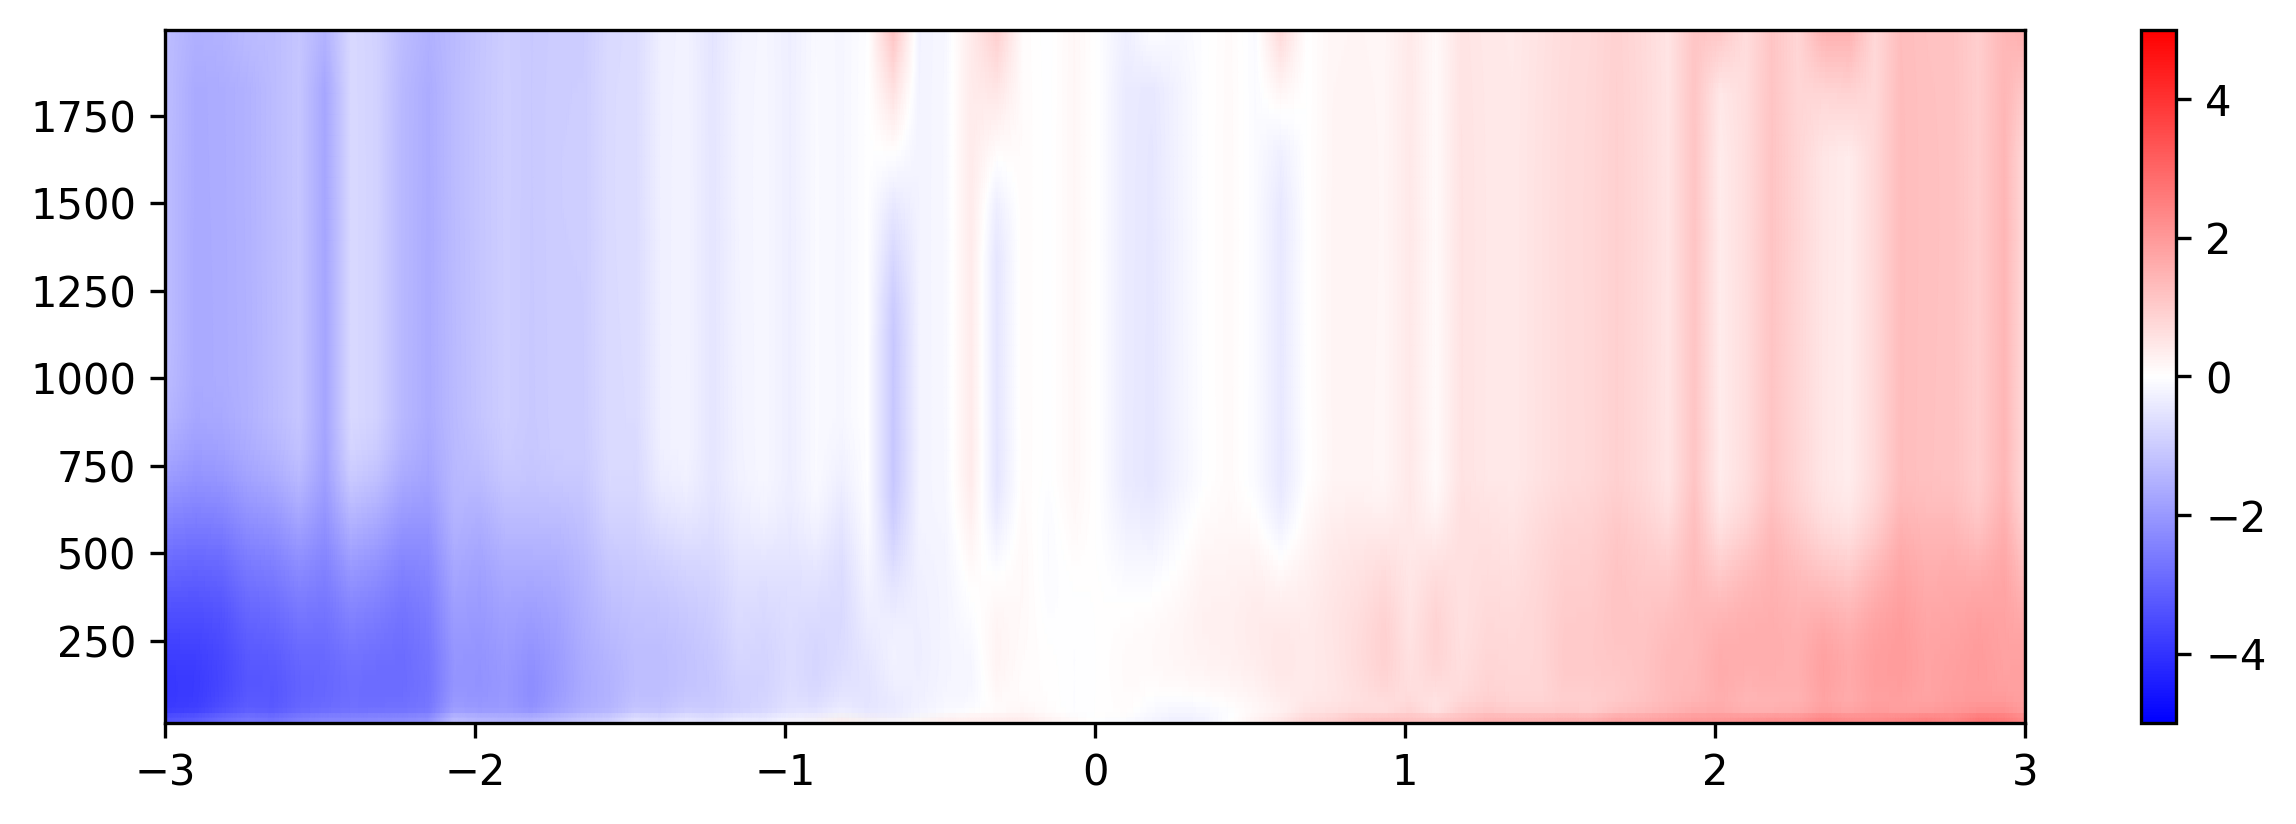

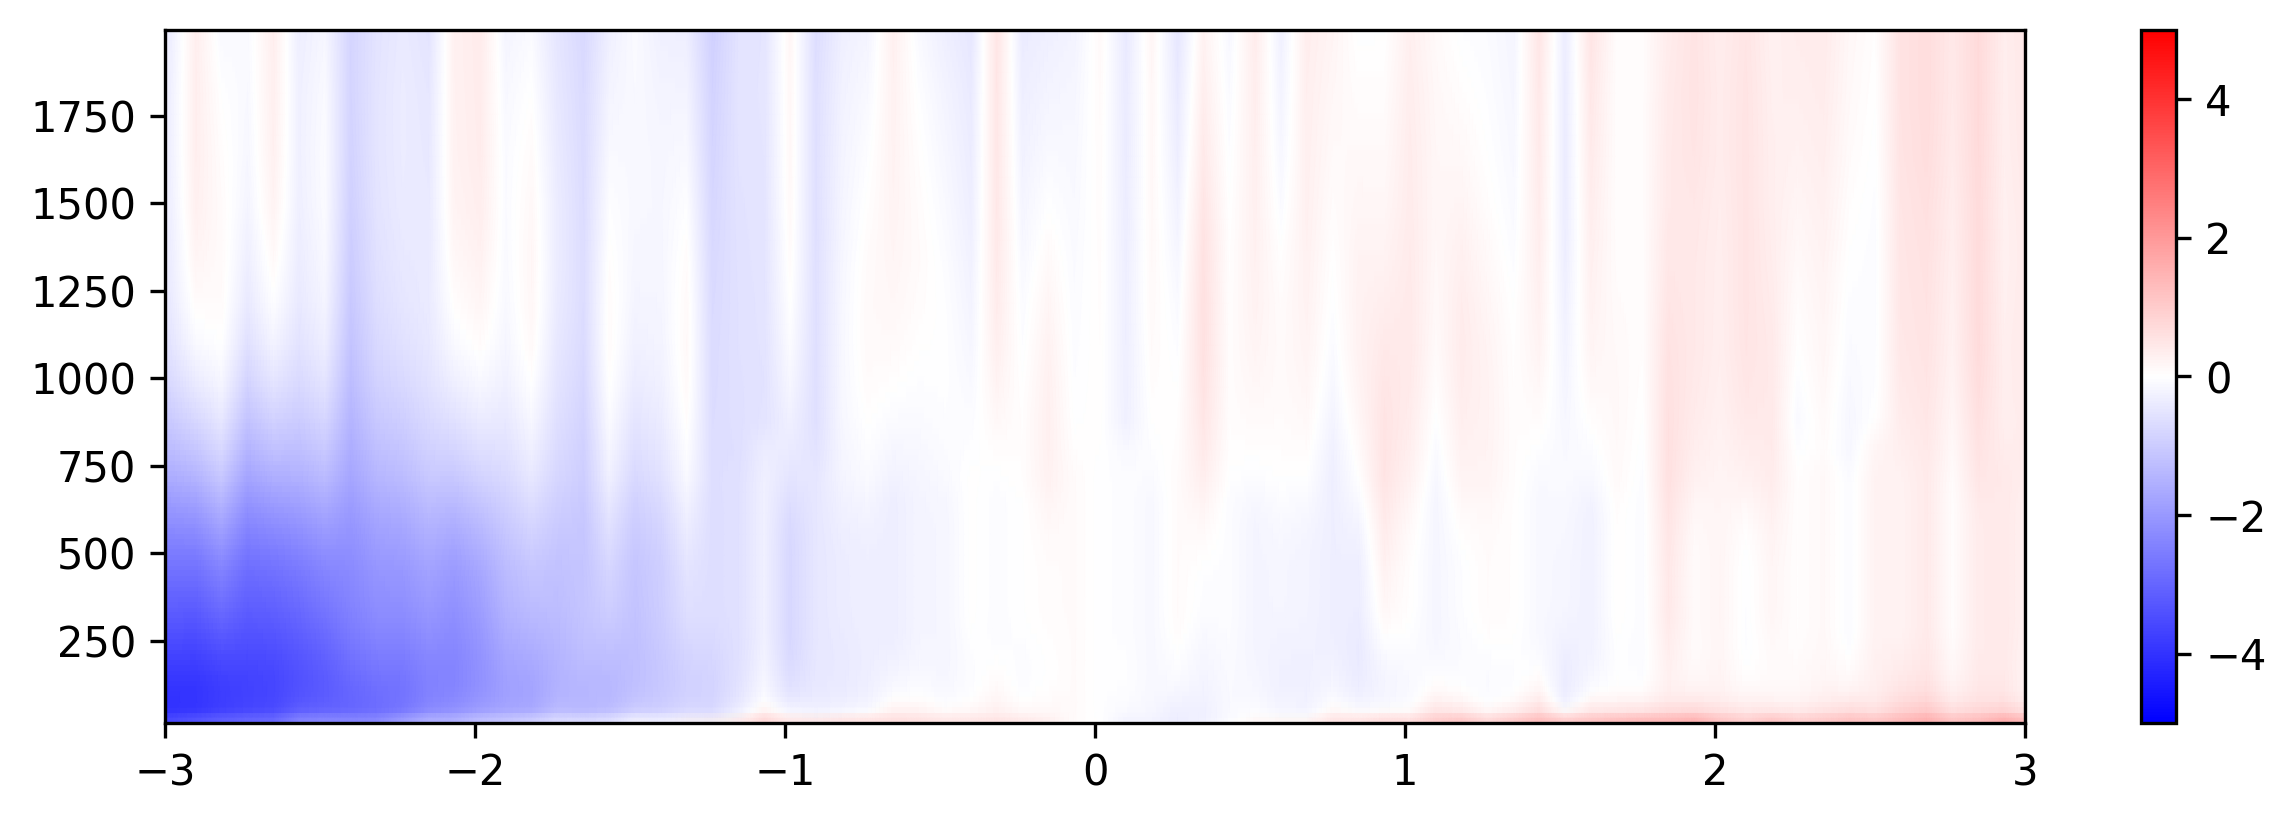

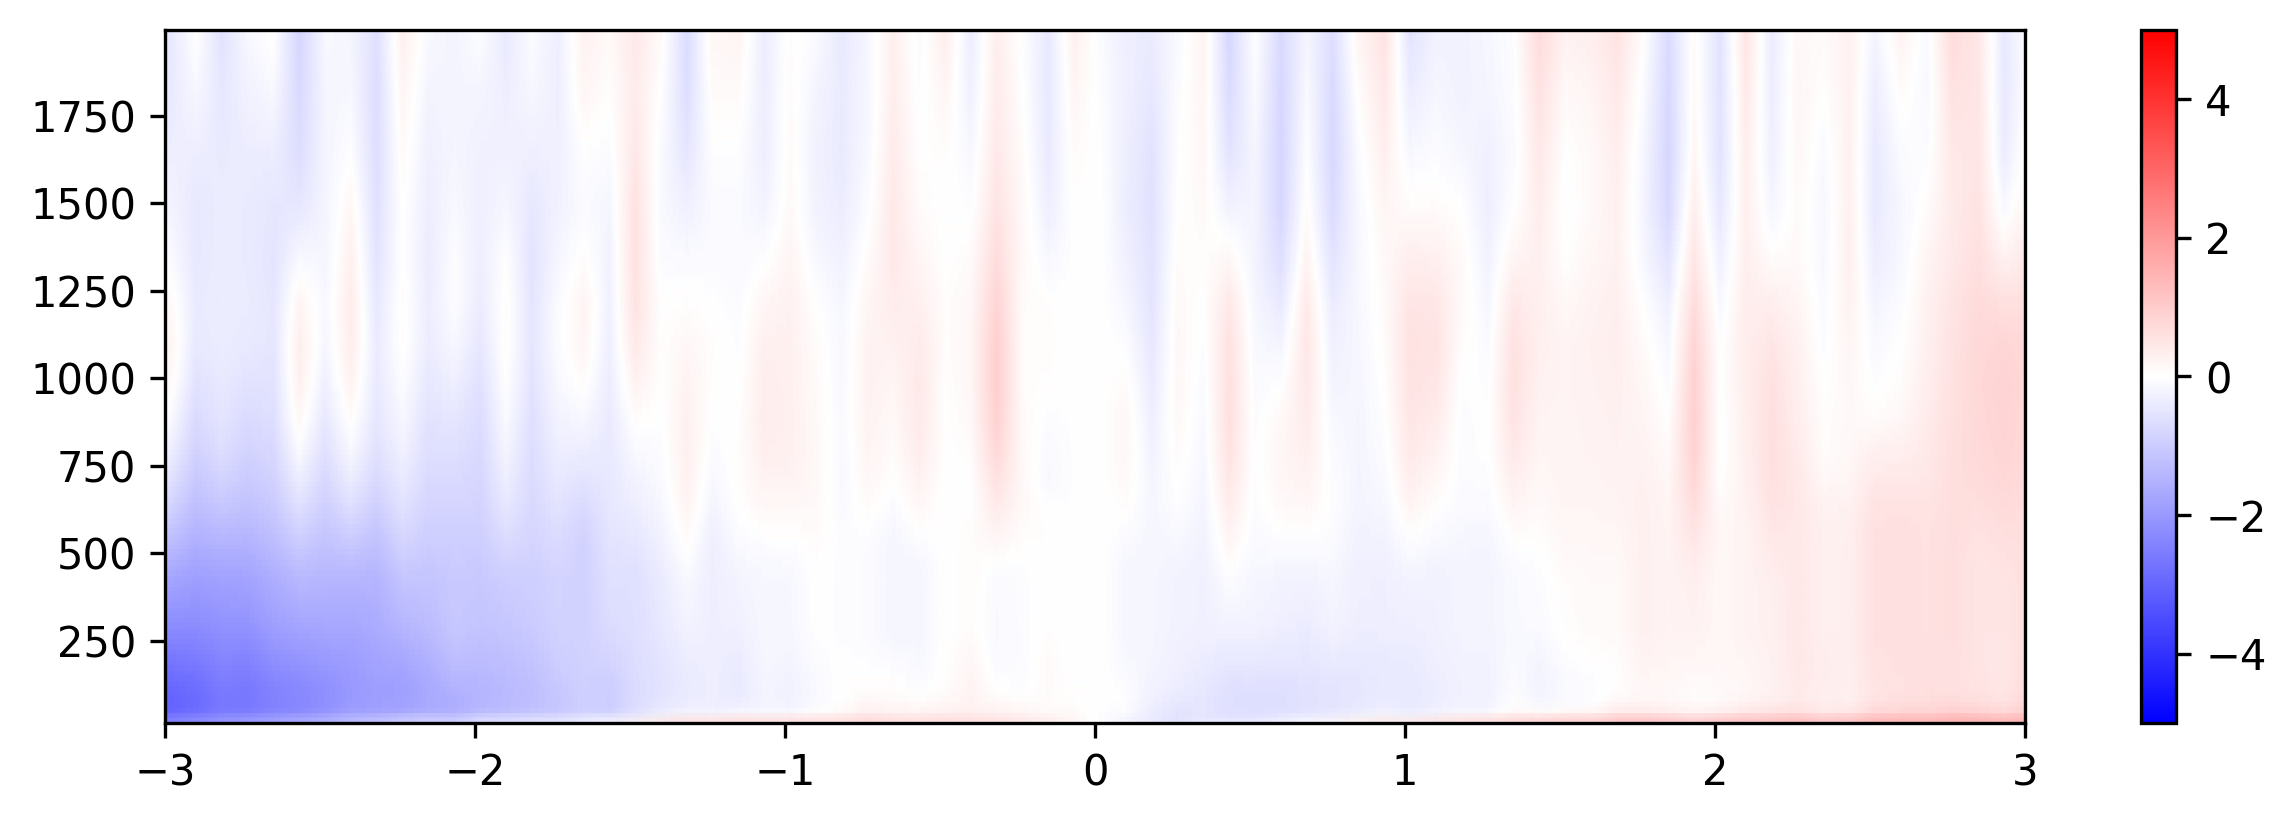

In [22]:
deltaT = np.zeros((len(timeNew), len(heightNew), len(eclipseSites)*len(eclipseDates)))-9999
pblz = np.zeros((len(timeNew), len(eclipseSites)*len(eclipseDates)))-9999
pblzidx = np.zeros(len(eclipseSites)*len(eclipseDates))-9999

ctr = 0

for g in np.arange(len(eclipseSites)):

    for h in np.arange(len(eclipseDates)):

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
            aeri = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
                aeri0 = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
                
                aeri.time = np.concatenate((aeri0.time-24, aeri.time))
                aeri.temp= np.concatenate((aeri0.temp, aeri.temp))
                aeri.wv= np.concatenate((aeri0.wv, aeri.wv))
                aeri.theta= np.concatenate((aeri0.theta, aeri.theta))
                aeri.sigma_t= np.concatenate((aeri0.sigma_t, aeri.sigma_t))
                
            
            
            dl.time = dl.time - eclipseTimes[h]
            aeri.time = aeri.time - eclipseTimes[h]

            #pblh_cbl(time,height,theta_prof,sigma):
  
            pbli = pblh_cbl(aeri.time, aeri.height/1000, aeri.theta, aeri.sigma_t)
            
            interpPbl = interp.interp1d(aeri.time, pbli)
            pblz[:,ctr] = interpPbl(timeNew)
            pblzidx[ctr]=h
               
        except Exception as e: 

            ctr = ctr+1
            continue
         
        interpFunc = interp.RectBivariateSpline(aeri.time, aeri.height[0:53], aeri.temp[:,0:53],kx=1, ky=1)
        tempNew = interpFunc(timeNew, heightNew)
        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)
        
        # plt.figure(figsize=(10, 3), dpi=300)
        # plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew),cmap = 'turbo', shading = 'gouraud')
        # cbar = plt.colorbar()
        # plt.clim(5,30) 
        # plt.xlim(-3,3)
        # plt.show()
        
 
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)

        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew-meanTprof),cmap = 'bwr', shading = 'gouraud')
        cbar = plt.colorbar()
        plt.clim(-5,5)
        plt.xlim(-3,3)
        plt.show()
        
        deltaT[:,:,ctr] = (tempNew-meanTprof)
        ctr = ctr+1
        
        
deltaT[np.where(deltaT==-9999)]=np.nan
pblz[np.where(pblz==-9999)]=np.nan

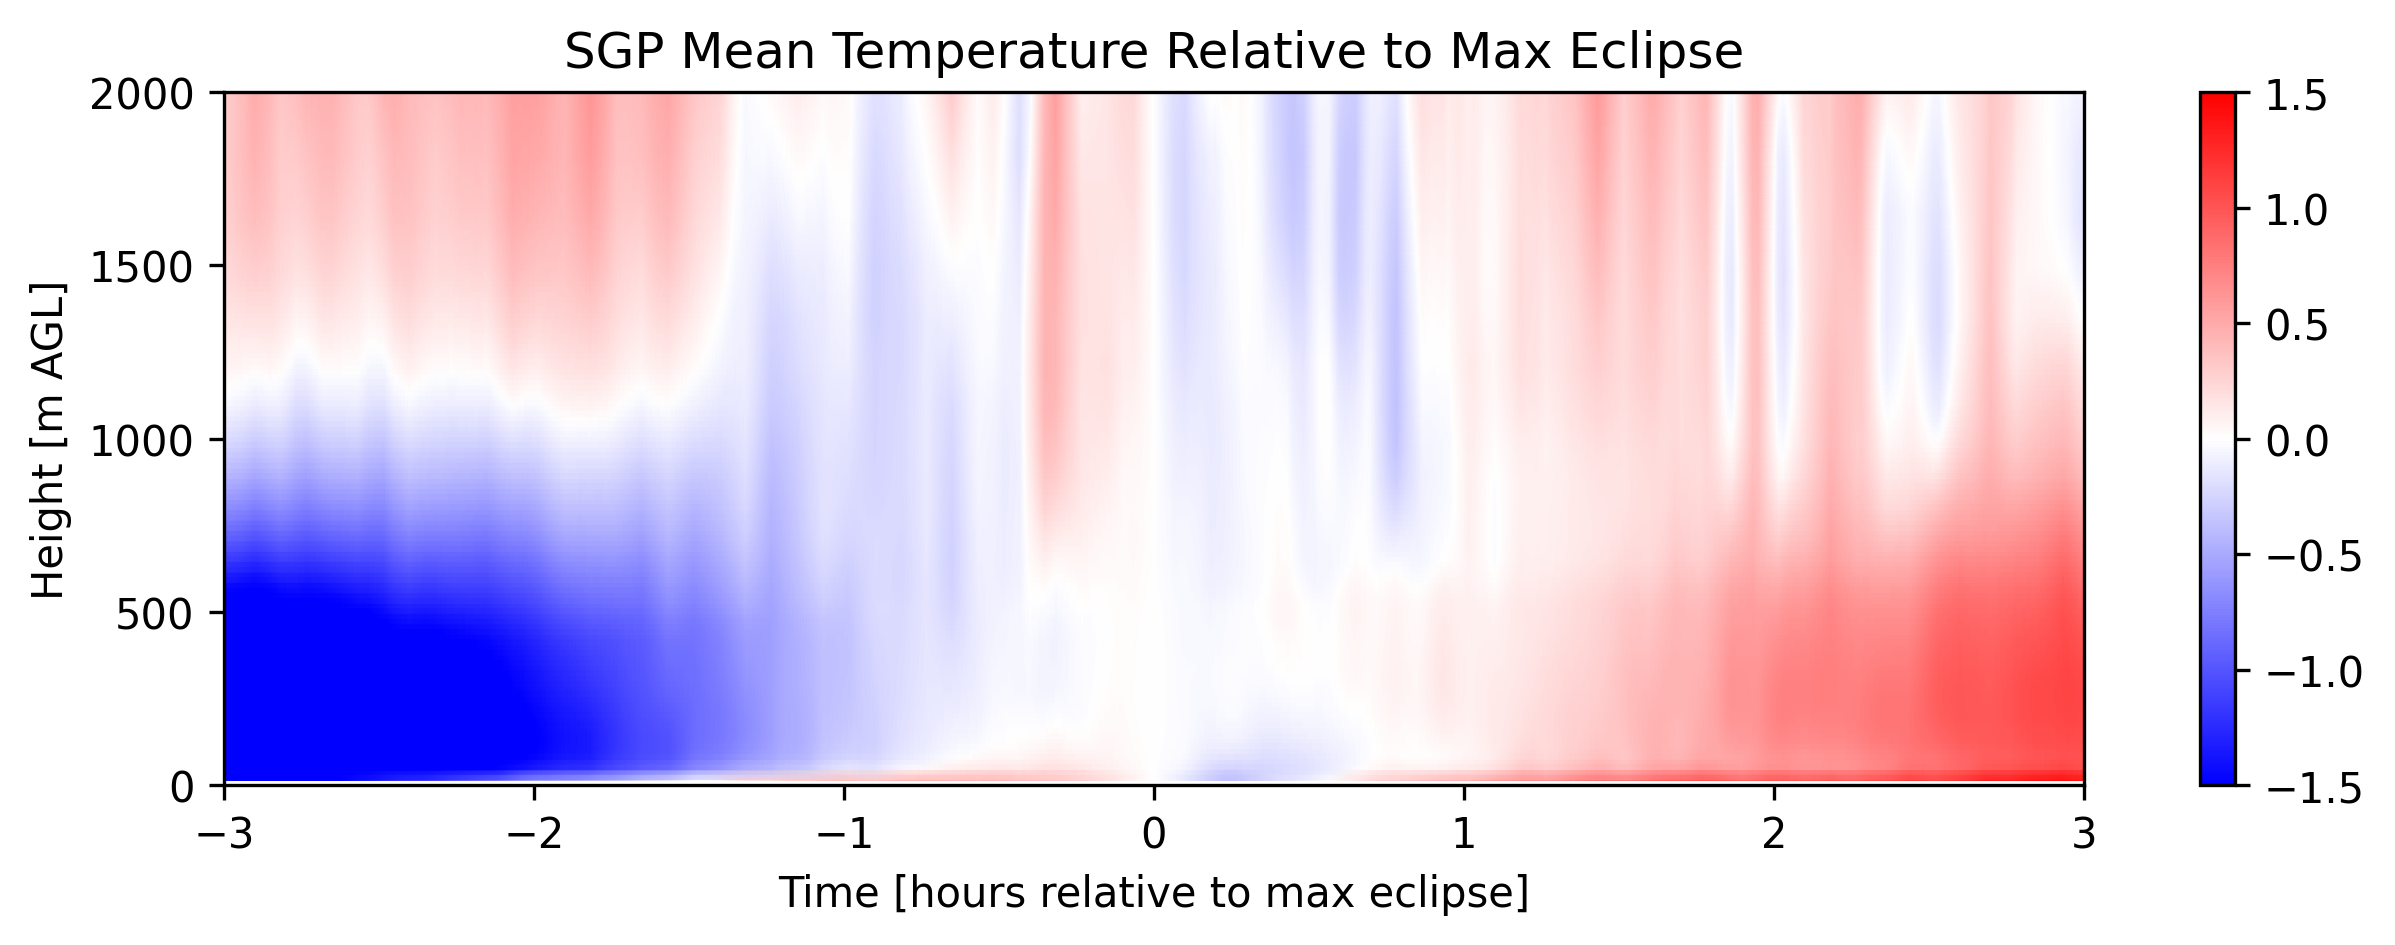

In [8]:
plt.figure(figsize=(10, 3), dpi=300)
plt.pcolormesh(timeNew, heightNew, np.transpose(np.nanmean(deltaT,2)),cmap = 'bwr', shading = 'gouraud')
cbar = plt.colorbar()
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.title('SGP Mean Temperature Relative to Max Eclipse')
plt.ylim(0,2000.01)

plt.show()





In [9]:
print(pblz)



[[1.27120697 0.3600633  0.04654759 ...        nan        nan        nan]
 [1.27157786 0.36020018 0.0465412  ...        nan        nan        nan]
 [1.27194874 0.36033706 0.04653481 ...        nan        nan        nan]
 ...
 [0.01062591 1.57119963 1.09273632 ...        nan        nan        nan]
 [0.01062335 1.57306448 1.09262024 ...        nan        nan        nan]
 [0.01062079 1.57492934 1.09250417 ...        nan        nan        nan]]


In [10]:
print(pblz)

[[1.27120697 0.3600633  0.04654759 ...        nan        nan        nan]
 [1.27157786 0.36020018 0.0465412  ...        nan        nan        nan]
 [1.27194874 0.36033706 0.04653481 ...        nan        nan        nan]
 ...
 [0.01062591 1.57119963 1.09273632 ...        nan        nan        nan]
 [0.01062335 1.57306448 1.09262024 ...        nan        nan        nan]
 [0.01062079 1.57492934 1.09250417 ...        nan        nan        nan]]


ValueError: x and y can be no greater than 2D, but have shapes (28801,) and (28801, 1, 1)

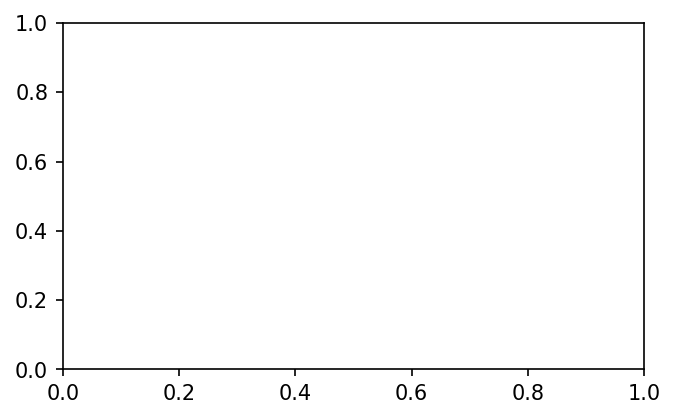

In [30]:
labels=[]

for i in np.arange(0,len(pblzidx)):
    
    ix = int(pblzidx[i])

    if ix != -9999:
    
        lab1 = str(eclipseDates[ix]) + ' ' + str(eclipseMags[ix])
        labels.append(lab1)
        
    else:

        labels.append('xxxx')

plt.figure(figsize=(5, 3), dpi=150)


for i in np.arange(0,len(eclipseDates)):
    
    ix = np.where(pblzidx == i)
    objs = plt.plot(timeNew, pblz[:,ix],color='black')
    plt.legend(objs, lab1[ix[0]])
    
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')

plt.grid()
plt.xlim(-3.3)
plt.title('PBLH Relative to Max Eclipse')
plt.show()

In [35]:
print(ix[0])

[0]
